# **Diplomado IA: Aplicaciones 1 - NLP**. <br> Práctico 2: Word Embeddings
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)

---
---

# **Instrucciones Generales**


El siguiente práctico es **individual**. El formato de entrega es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondidas en las celdas dispuestas para ello. No se aceptará el _output_ de una celda de código como respuesta.

Este práctico cuenta con varias secciones y en varias de ellas se incluye actividades a realizar.

**IMPORTANTE: habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0**

# **Importamos librerías a usar**

In [1]:
!pip install gensim

**Importante**: Luego de instalar `gensim`, se recomienda reiniciar el entorno de ejecución para asegurar la correcta carga de las bibliotecas actualizadas.

In [2]:
import re
import gdown
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import nltk
import gensim
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
from gensim.models.keyedvectors import KeyedVectors
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# **Descargamos Word2vec pre-entrenado**

In [3]:
# url = 'https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz'
# url = 'https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM'
url = 'https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe'
output = 'GoogleNews-vectors-negative300.bin.gz'
gdown.download(url, output, quiet=False)

# Otras opciones encontradas en Google:
# https://github.com/mmihaltz/word2vec-GoogleNews-vectors/blob/master/GoogleNews-vectors-negative300.bin.gz
# https://figshare.com/articles/dataset/GoogleNews-vectors-negative300/23601195?file=41403483
# https://huggingface.co/NathaNn1111/word2vec-google-news-negative-300-bin/tree/main

Downloading...
From (original): https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe
From (redirected): https://drive.google.com/uc?id=1JSZ_T94Kq0AbKC7qXiIqZKDe3xpBuySe&confirm=t&uuid=486cb062-5df5-41c2-9685-0fa19b7c43a6
To: /content/GoogleNews-vectors-negative300.bin.gz
100%|██████████| 1.65G/1.65G [00:21<00:00, 77.0MB/s]


'GoogleNews-vectors-negative300.bin.gz'

In [4]:
!ls -la /content/GoogleNews-vectors-negative300.bin.gz

-rw-r--r-- 1 root root 1647046227 Nov 10  2022 /content/GoogleNews-vectors-negative300.bin.gz


In [5]:
google_wordvecs = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True, limit=100000)

# **Analogías con Word2vec**
## (Álgebra de vectores con interpretación semántica)

Inspirado y basado en: https://github.com/dccuchile/spanish-word-embeddings/blob/master/examples/Ejemplo_WordVectors.ipynb

Ejemplo de uso: most_similar_cosmul(positive=lista_palabras_positivas, negative=lista_palabras_negativas)

Esta llamada encuentra las palabras del vocabulario que están más cercanas a las palabras en listas_palabras_positivas y no estén cercanas a lista_palabras_negativas (para una formalización del procedimiento, ver la fórmula (4) en la Sección 6 de este [artículo](http://www.aclweb.org/anthology/W14-1618)).

Cuando lista_palabras_positivas contiene dos palabras, digamos a y b_p, y lista_palabras_negativas contiene una palabra, digamos a_p, el anterior procedimiento se lee coloquialmente como el encontrar la palabra b que responde a la pregunta: a_p es a a como b_p es a ???. El ejemplo clásico se tiene cuando a es rey, b_p es mujer, y a_p es hombre. La palabra buscada b es reina, pues hombre es a rey como mujer es a reina.

In [6]:
google_wordvecs.most_similar_cosmul(positive=['woman','king'], negative=['queen']) # woman - queen + king = man

[('man', 0.9307777285575867),
 ('boy', 0.8291134238243103),
 ('motorcyclist', 0.7735416293144226),
 ('teenage_girl', 0.7693272233009338),
 ('teenager', 0.7692983746528625),
 ('taxi_driver', 0.7674799561500549),
 ('girl', 0.7596036195755005),
 ('victim', 0.7527119517326355),
 ('bicyclist', 0.7488752603530884),
 ('father', 0.7468025088310242)]

In [7]:
google_wordvecs.most_similar_cosmul(positive=['actor','woman'],negative=['man'])

[('actress', 1.0588080883026123),
 ('actresses', 0.9304280281066895),
 ('Best_Actress', 0.8946203589439392),
 ('Actress', 0.8936436772346497),
 ('comedienne', 0.8506139516830444),
 ('Best_Supporting_Actress', 0.8503092527389526),
 ('actors', 0.8433448076248169),
 ('Paltrow', 0.8427857160568237),
 ('Heigl', 0.8372300267219543),
 ('Golden_Globe', 0.8350875973701477)]

In [8]:
google_wordvecs.most_similar_cosmul(positive=['son','woman'],negative=['man'])

[('daughter', 1.053764820098877),
 ('mother', 1.0130525827407837),
 ('niece', 0.9732571840286255),
 ('eldest_daughter', 0.9666094779968262),
 ('granddaughter', 0.95781010389328),
 ('husband', 0.956787109375),
 ('daughters', 0.9557827115058899),
 ('sister', 0.9450976252555847),
 ('father', 0.9181194305419922),
 ('wife', 0.9142286777496338)]

In [9]:
google_wordvecs.most_similar_cosmul(positive=['play','singing'],negative=['sing']) # play - sing + singing = playing

[('playing', 0.9153854846954346),
 ('played', 0.8183861374855042),
 ('game', 0.8155624866485596),
 ('plays', 0.8033236861228943),
 ('Playing', 0.7878930568695068),
 ('games', 0.7651411294937134),
 ('scoring', 0.7445952892303467),
 ('physicality', 0.7320943474769592),
 ('Play', 0.728746771812439),
 ('playmaking', 0.7280517220497131)]

In [10]:
google_wordvecs.most_similar_cosmul(positive=['play','sang'],negative=['sing'])

[('played', 0.9050213694572449),
 ('playing', 0.8536635637283325),
 ('plays', 0.8203080296516418),
 ('Playing', 0.7951124310493469),
 ('game', 0.7891286015510559),
 ('Played', 0.7801413536071777),
 ('played_sparingly', 0.7400324940681458),
 ('games', 0.737052321434021),
 ('outplayed', 0.7354370951652527),
 ('ball', 0.7341139316558838)]

In [11]:
# Probar si la dirección "pasado" es reutilizable
verbs_pares_pasado = [
    ('walk', 'walked'),      # regular
    ('eat', 'ate'),          # irregular
    ('run', 'ran'),          # irregular
    ('study', 'studied'),    # regular
]

print(f"Distancia entre direcciones 'pasado' (debería ser BAJA si Word2Vec generaliza):\n")
for v1, p1 in verbs_pares_pasado:
    for v2, p2 in verbs_pares_pasado:
        if v1 < v2:
            d1 = google_wordvecs[p1] - google_wordvecs[v1]
            d2 = google_wordvecs[p2] - google_wordvecs[v2]
            cos = np.dot(d1, d2) / (np.linalg.norm(d1) * np.linalg.norm(d2))
            print(f"  cos({p1}-{v1}, {p2}-{v2}) = {cos:.3f}")


Distancia entre direcciones 'pasado' (debería ser BAJA si Word2Vec generaliza):

  cos(ate-eat, walked-walk) = 0.486
  cos(ate-eat, ran-run) = 0.395
  cos(ate-eat, studied-study) = 0.187
  cos(ran-run, walked-walk) = 0.597
  cos(ran-run, studied-study) = 0.153
  cos(studied-study, walked-walk) = 0.245


In [12]:
google_wordvecs.most_similar_cosmul(positive=['Santiago','Venezuela'],negative=['Chile'])

[('Caracas', 0.9518518447875977),
 ('Ramírez', 0.9386518597602844),
 ('Peña', 0.9186561703681946),
 ('Chavez', 0.9147828221321106),
 ('Rodríguez', 0.9133160710334778),
 ('Martinez', 0.9109025001525879),
 ('Ramirez', 0.9093917608261108),
 ('Ortiz', 0.9087135791778564),
 ('Venezuelan', 0.9070562124252319),
 ('Martínez', 0.9041159749031067)]

In [13]:
import numpy as np

# Dirección capital → país (¿es reutilizable?)
d1 = google_wordvecs['Santiago'] - google_wordvecs['Chile']
d2 = google_wordvecs['Caracas']  - google_wordvecs['Venezuela']
d3 = google_wordvecs['Lima']     - google_wordvecs['Peru']
d4 = google_wordvecs['Tokyo']    - google_wordvecs['Japan']

def cos(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print(f"cos(Santiago-Chile, Caracas-Venezuela) = {cos(d1, d2):.3f}")
print(f"cos(Santiago-Chile, Lima-Peru)         = {cos(d1, d3):.3f}")
print(f"cos(Santiago-Chile, Tokyo-Japan)       = {cos(d1, d4):.3f}")
print(f"cos(Caracas-Venezuela, Tokyo-Japan)    = {cos(d2, d4):.3f}")


cos(Santiago-Chile, Caracas-Venezuela) = 0.410
cos(Santiago-Chile, Lima-Peru)         = 0.543
cos(Santiago-Chile, Tokyo-Japan)       = 0.411
cos(Caracas-Venezuela, Tokyo-Japan)    = 0.657


In [14]:
# Reemplazar Santiago por un nombre menos polisémico para comparar
import numpy as np
def cos(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Capitales monosémicas
pares_monosemic = [
    ('Tokyo', 'Japan'),
    ('Caracas', 'Venezuela'),
    ('Stockholm', 'Sweden'),
    ('Brussels', 'Belgium'),
    ('Helsinki', 'Finland'),
]

print("Cosenos entre direcciones capital→país (todos monosémicos):\n")
dirs = {f"{cap}-{country}": google_wordvecs[cap] - google_wordvecs[country]
        for cap, country in pares_monosemic}

for k1, v1 in dirs.items():
    for k2, v2 in dirs.items():
        if k1 < k2:
            print(f"  cos({k1}, {k2}) = {cos(v1, v2):.3f}")


Cosenos entre direcciones capital→país (todos monosémicos):

  cos(Caracas-Venezuela, Tokyo-Japan) = 0.657
  cos(Caracas-Venezuela, Stockholm-Sweden) = 0.529
  cos(Caracas-Venezuela, Helsinki-Finland) = 0.521
  cos(Stockholm-Sweden, Tokyo-Japan) = 0.699
  cos(Brussels-Belgium, Tokyo-Japan) = 0.483
  cos(Brussels-Belgium, Caracas-Venezuela) = 0.404
  cos(Brussels-Belgium, Stockholm-Sweden) = 0.484
  cos(Brussels-Belgium, Helsinki-Finland) = 0.485
  cos(Helsinki-Finland, Tokyo-Japan) = 0.651
  cos(Helsinki-Finland, Stockholm-Sweden) = 0.719


In [15]:
google_wordvecs.most_similar_cosmul(positive=['Buenos_Aires','Chile'],negative=['Santiago']) # Chile - Santiago + Buenos_Aires = Argentina

[('Argentina', 1.0106027126312256),
 ('Brazil', 0.9226211905479431),
 ('Uruguay', 0.8886619210243225),
 ('Chilean', 0.8861171007156372),
 ('Argentine', 0.879367470741272),
 ('Argentines', 0.8666806221008301),
 ('Peru', 0.8634063005447388),
 ('Paraguay', 0.863052248954773),
 ('Bolivia', 0.8587836623191833),
 ('President_Nestor_Kirchner', 0.8434462547302246)]

**Actividad 1**

Use su creatividad y genere 3 ejemplos adicionales de analogías, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Funcionaron las analogías como usted esperaba? ¿Sí, no, por qué? ¿Le hacen sentido las top 10 palabras? ¿Hay alguna palabra que no le hace sentido?

Utilice las 3 celdas abajo para generar sus ejemplos.

NOTA: se recomienda hacerlo con palabras en inglés.

In [16]:
for w in ['saxophone', 'classical', 'jazz', 'violin', 'piano', 'flute',
          'Yankees', 'basketball', 'baseball', 'Lakers', 'Knicks',
          'Microsoft', 'iPhone', 'Apple', 'Windows_Phone', 'Surface', 'Lumia', 'Xbox']:
    presente = w in google_wordvecs.key_to_index
    print(f"{w:20s}: {'✅' if presente else '❌'}")


saxophone           : ✅
classical           : ✅
jazz                : ✅
violin              : ✅
piano               : ✅
flute               : ✅
Yankees             : ✅
basketball          : ✅
baseball            : ✅
Lakers              : ✅
Knicks              : ✅
Microsoft           : ✅
iPhone              : ✅
Apple               : ✅
Windows_Phone       : ✅
Surface             : ✅
Lumia               : ❌
Xbox                : ✅


In [17]:
google_wordvecs.most_similar_cosmul(positive=['saxophone','classical'], negative=['jazz'])
# jazz - saxophone + classical = violin (o piano)

[('cello', 0.8610683083534241),
 ('violin', 0.8609269261360168),
 ('flute', 0.8336731195449829),
 ('sitar', 0.8325433135032654),
 ('clarinet', 0.8267018795013428),
 ('oboe', 0.8257735967636108),
 ('viola', 0.8246648907661438),
 ('piano', 0.8158342242240906),
 ('tabla', 0.8153531551361084),
 ('trombone', 0.8045398592948914)]

In [18]:
google_wordvecs.most_similar_cosmul(positive=['Yankees','basketball'], negative=['baseball'])
# baseball - Yankees + basketball = Lakers (o equipo NBA emblemático)

[('Knicks', 0.8792563080787659),
 ('Nets', 0.8579695820808411),
 ('Pistons', 0.85578852891922),
 ('Cavs', 0.8407180905342102),
 ('Detroit_Pistons', 0.8368415236473083),
 ('New_Jersey_Nets', 0.8343371152877808),
 ('Celtics', 0.8333585262298584),
 ('Cleveland_Cavaliers', 0.832636296749115),
 ('Miami_Heat', 0.8292175531387329),
 ('McDyess', 0.8192357420921326)]

In [19]:
google_wordvecs.most_similar_cosmul(positive=['Microsoft','iPhone'], negative=['Apple'])
# Apple - iPhone + Microsoft = Windows_Phone (o Surface, productos Microsoft)

[('Windows_Mobile', 0.8599113821983337),
 ('Windows_Vista', 0.8435086607933044),
 ('Windows_Phone', 0.8426169753074646),
 ('Windows', 0.8414987921714783),
 ('WP7', 0.839320182800293),
 ('Internet_Explorer', 0.8390304446220398),
 ('MSN_Messenger', 0.8382024168968201),
 ('Windows_Live', 0.8344401121139526),
 ('Windows_Phone_7', 0.832115650177002),
 ('Visual_Studio', 0.829556405544281)]

**Comente aquí sus ejemplos**:

## Ejemplo 1: Música — analogía instrumentos x géneros

**Analogía**: "jazz es a saxophone como classical es a ?"

**Código**:
```python
google_wordvecs.most_similar_cosmul(
    positive=['saxophone','classical'], negative=['jazz'])
```

**Hipótesis previa**: Espero que el modelo responda `violin` o
`piano` por ser los instrumentos icónicos de la música clásica
occidental.

**Resultado**: top-1 = `cello` (0.8611), top-2 = `violin` (0.8609) —
prácticamente empate técnico (gap 0.0001). Las posiciones 3-10 son
flute, sitar, clarinet, oboe, viola, piano, tabla, trombone.

**Análisis**:
1. La analogía funcionó estructuralmente: 10/10 resultados son
   instrumentos, sin contaminación de palabras de jazz (saxophone,
   trumpet, bass).

2. Sorpresa: aparecen sitar (#4) y tabla (#9), instrumentos de música
   CLÁSICA INDIA. Esto revela que `classical` es polisémica
   culturalmente: el corpus de Google News asocia el término tanto a
   tradición occidental (Bach, orquesta) como a la india ("Indian
   classical music").

3. Cello le gana marginalmente a violin (gap 0.0001) probablemente
   porque cello aparece casi exclusivamente en contextos clásicos,
   mientras que violin tiene usos diluidos en country, folk, por ejemplo.

**Conclusión**: el método funciona pero revela polisemia cultural
(classical = occidental + indio), un fenómeno que se suma a las
otras formas de polisemia ya documentadas en la literatura
(ortográfica, léxica, funcional).

## Ejemplo 2: Deportes — analogía cross-deporte

**Analogía**: "baseball es a Yankees como basketball es a ?"

**Código**:
```python
google_wordvecs.most_similar_cosmul(
    positive=['Yankees','basketball'], negative=['baseball'])
```

**Hipótesis previa**: esperaba que el modelo respondiera `Lakers` por
ser el equipo NBA más legendario (paralelo a "Yankees = más exitoso
del baseball").

**Resultado**: top-1 = `Knicks` (0.8793). El top-10 efectivo (sin
duplicados con/sin ciudad completa) fue: Knicks, Nets, Pistons,
Cavs, Celtics, Heat, McDyess.

**Análisis**:
1. **Lakers NO aparece en el top-10**. El modelo NO capturó "Yankees =
   campeón legendario" sino "Yankees = equipo de Nueva York / costa
   este". Los 6 equipos en el top-10 son TODOS de la Conferencia Este
   de la NBA, encabezados por los del área NY (Knicks, Nets).
2. Esta dimensión geográfica refleja que en prensa, `Yankees`
   co-ocurre más frecuentemente con "New York", "Yankee Stadium" que con "world champions".
3. El gap top-1 vs top-2 fue 0.021, moderado-bajo, reflejando que
   Knicks y Nets son ambos plausibles como "equipo NBA del área NY".

**Conclusión**: el método funcionó parcialmente — recuperó el cluster
NBA correctamente — pero proyectó la analogía sobre la dimensión
geográfica (NY → este) en vez de la dimensión esperada
(éxito/legendariedad). Esto revela que la "dimensión dominante" de
una palabra polisémica depende del peso relativo de sus
co-ocurrencias en el corpus, no de la intuición humana sobre qué
debería ser "más importante".

## Ejemplo 3: Tecnología — analogía empresa x producto

**Analogía**: "Apple es a iPhone como Microsoft es a ?"

**Código**:
```python
google_wordvecs.most_similar_cosmul(
    positive=['Microsoft','iPhone'], negative=['Apple'])
```

**Hipótesis previa**: predije una mezcla de productos Microsoft
mobile (Windows_Phone, Surface) y productos legacy (Windows, Office,
Xbox).

**Resultado**: top-1 = `Windows_Mobile` (0.8599), seguido de
Windows_Vista, Windows_Phone, Windows, WP7, Internet_Explorer,
MSN_Messenger, Windows_Live, Windows_Phone_7, Visual_Studio.

**Análisis**:
1. La analogía funcionó MEJOR de lo esperado. 4 de los 10 resultados
   son específicamente sistemas operativos MÓVILES de Microsoft
   (Windows_Mobile, Windows_Phone, WP7, Windows_Phone_7),
   confirmando que el modelo capturó la dimensión "smartphone de
   Microsoft" correctamente.
2. Top-1 fue `Windows_Mobile` (2003-2010, descontinuado) en vez de
   `Windows_Phone` (2010-2017, vigente al entrenamiento). Esto se
   debe a que Windows_Mobile tenía 7 años de acumulación periodística
   contra solo 3 de Windows_Phone. **Los embeddings reflejan el peso
   acumulado de cobertura, no el estado actual al momento del
   entrenamiento**.
3. Productos esperables como `Surface` (tablet/laptop insignia 2012),
   `Xbox` y `Office` NO aparecen en el top-10. Hipótesis: al cancelar
   `Apple` en negative, se canceló también la dimensión "producto
   insignia tecnológica" (Apple tiene iPad/MacBook/iWork/iTunes que
   se solapan con Surface/Office/Xbox), dejando solo el cluster más
   específicamente Microsoft software.

**Conclusión**: la analogía corporativa empresa-producto funciona,
pero el resultado se inclina hacia productos LEGACY con más
cobertura acumulada en el corpus, no hacia productos vigentes.
Adicionalmente, la palabra en `negative` cancela DIMENSIONES enteras
del espacio (no solo palabras específicas), lo que puede eliminar
respuestas válidas si esas dimensiones se solapan con el repulsor.

## Conclusión global

Las tres analogías ejecutadas funcionaron ESTRUCTURALMENTE (top-1
siempre fue una respuesta plausible al dominio), pero cada una
reveló una limitación distinta del método:

1. **Ejemplo 1 (música)** mostró que `classical` tiene POLISEMIA
   CULTURAL (occidental + india).

2. **Ejemplo 2 (deportes)** mostró que el modelo proyecta la
   analogía sobre la dimensión MÁS PROMINENTE estadísticamente
   en el corpus (Yankees = NY/costa este), no sobre la dimensión
   que humanamente consideraríamos "principal" (Yankees = más
   exitoso).

3. **Ejemplo 3 (tecnología)** mostró DOS fenómenos: (a) sesgo
   temporal hacia productos legacy con más cobertura acumulada
   (Windows_Mobile descontinuado supera a Windows_Phone vigente);
   (b) la palabra en `negative` cancela DIMENSIONES enteras del
   espacio, no solo palabras específicas. Apple no solo cancela
   "iPhone" sino toda la categoría "producto insignia
   tecnológica", lo que explica la ausencia de Surface, Xbox,
   Office.

# **Word vectors en términos excluídos**

Ejemplo de uso: doesnt_match(lista_palabras)

Esta llamada selecciona la palabra dentro de listas_palabras que está más lejana del resto de las palabras de la lista. La distancia es simplemente el ángulo entre las direcciones de los vectores de las palabras.

In [20]:
google_wordvecs.doesnt_match(['white','blue','red','Chile'])

'Chile'

In [21]:
google_wordvecs.doesnt_match(['Sun','Moon','lunch','Jupiter'])

'lunch'

In [22]:
google_wordvecs.doesnt_match(['April', 'May', 'September', 'Tuesday', 'July'])

'Tuesday'

In [23]:
google_wordvecs.doesnt_match(['Monday', 'Tuesday', 'September', 'Thursday', 'Friday'])

'September'

In [24]:
google_wordvecs.doesnt_match(['Lima', 'Paris', 'London', 'Madrid'])

'Lima'

**Actividad 2**

Use su creatividad y genere 3 ejemplos adicionales de términos excluídos, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Le funcionaron sus ejemplos como usted esperaba? ¿Sí, no, por qué?

Utilice las 3 celdas abajo para generar sus ejemplos.

In [25]:
for w in ['guitar', 'piano', 'violin', 'baseball',
          'NBA', 'NFL', 'NHL', 'FIFA',
          'Lakers', 'Yankees', 'Celtics', 'Bulls',
          'Microsoft', 'Apple', 'Google', 'Amazon', 'Tesla']:
    presente = w in google_wordvecs.key_to_index
    print(f"{w:15s}: {'✅' if presente else '❌'}")


guitar         : ✅
piano          : ✅
violin         : ✅
baseball       : ✅
NBA            : ✅
NFL            : ✅
NHL            : ✅
FIFA           : ✅
Lakers         : ✅
Yankees        : ✅
Celtics        : ✅
Bulls          : ✅
Microsoft      : ✅
Apple          : ✅
Google         : ✅
Amazon         : ✅
Tesla          : ✅


In [26]:
google_wordvecs.doesnt_match(['guitar', 'piano', 'violin', 'baseball'])
# 3 instrumentos + 1 deporte → intrusa: baseball

'baseball'

In [27]:
google_wordvecs.doesnt_match(['Lakers', 'Yankees', 'Celtics', 'Bulls'])
# 3 equipos NBA + 1 equipo MLB → intrusa esperable: Yankees

'Yankees'

In [28]:
google_wordvecs.doesnt_match(['Microsoft', 'Apple', 'Google', 'Amazon'])
# 4 big tech con dominios solapados → respuesta NO obvia

'Amazon'

**Comente aquí sus ejemplos**:

# Comentario de Actividad 2 — Tres ejemplos de `doesnt_match`

Diseñé tres ejemplos de dificultad creciente para observar cómo
`doesnt_match` distingue entre palabras dentro de un grupo,
aprovechando la observación del Bloque guía (Celdas 26-30) de que
el método es más robusto a polisemia que `most_similar_cosmul`
porque promedia múltiples vectores en el centroide.

---

## Ejemplo 1 — Música (dominios disjuntos, trivial)

**Grupo**: `['guitar', 'piano', 'violin', 'baseball']`

**Hipótesis previa**: `baseball` debería salir como outlier porque
es la única palabra del dominio "deportes" en un grupo de
instrumentos musicales.

**Resultado**: `baseball` ✅

**Análisis**: caso trivial equivalente a las Celdas 26-27 del bloque
guía. Los tres instrumentos forman un cluster cohesivo de "música"
con centroide bien definido; baseball está en cluster
completamente disjunto (deportes), lejos del centroide. Sirve como
baseline para validar el método antes de explorar casos más finos.

---

## Ejemplo 2 — Deportes USA (test fino intra-dominio)

**Grupo**: `['Lakers', 'Yankees', 'Celtics', 'Bulls']`

**Hipótesis previa**: `Yankees` debería salir porque es el único
equipo de MLB en un grupo de equipos NBA históricos (Lakers,
Celtics, Bulls). Esperaba que la respuesta estuviera sobredeterminada
por tres dimensiones convergentes: (a) liga distinta, (b) ciudad
distinta (NY vs LA/Boston/Chicago), (c) tradición distinta (béisbol
vs baloncesto).

**Resultado**: `Yankees` ✅

**Análisis**: este caso es análogo a las Celdas 28-29 del bloque
guía (meses vs días), pero aplicado al dominio deportivo. Aunque los
4 son "equipos deportivos estadounidenses históricos" (mismo
super-dominio), el modelo distingue finamente entre sub-clusters
"NBA franquicias legendarias" vs "MLB Yankees".

---

## Ejemplo 3 — Big Tech (test impredecible)

**Grupo**: `['Microsoft', 'Apple', 'Google', 'Amazon']`

**Hipótesis previa**: este caso NO tenía respuesta obvia. Las cuatro
son gigantes tecnológicas estadounidenses pertenecientes al mismo
super-dominio. Apuesta moderada: `Amazon` por la combinación de
(a) ser primariamente retail (las otras 3 son software/hardware/
internet platform), (b) polisemia adicional (Amazon también es el
río y referencia mitológica).

**Resultado**: `Amazon` ✅

**Análisis**: el modelo capturó la dimensión **"retail vs tech
platform"** como la más prominente. En el corpus de Google News
pre-2013, Amazon era predominantemente conocida como "the online
retailer" — AWS lanzó en 2006 pero su cobertura mediática masiva
no llegó hasta 2015-2017, después del entrenamiento. Las otras 3
empresas (Microsoft, Apple, Google) forman un cluster cohesivo
"plataformas tecnológicas" (software empresarial, hardware
premium, búsqueda + Android), mientras Amazon permanece en cluster
"retail + logística + e-commerce". Esto refuerza el patrón temporal
documentado en otras analogías del lab: los embeddings reflejan el
peso ACUMULADO de cobertura, no el estado actual.

---

## Conclusión global

Los tres ejemplos confirman empíricamente lo observado en el bloque
guía: `doesnt_match` es **más robusto que `most_similar_cosmul`**
porque su mecanismo de centroide promedia múltiples vectores,
suavizando el ruido individual de palabras polisémicas.

La diferencia es estructural:

| Mecanismo | Sensibilidad a polisemia |
|---|---|
| 3CosMul (analogías) | Alta — un atractor polisémico contamina todo el ranking |
| Centroide (doesnt_match) | Baja — el promedio cancela ruido individual |

Tres observaciones adicionales valiosas:

1. **El modelo distingue sub-clusters dentro de un dominio**
   (NBA vs MLB en Ejemplo 2).

2. **El criterio de "outlier" no siempre coincide con la intuición
   humana**. En el Ejemplo 3 esperaba intuitivamente que Apple
   fuera la outlier (hardware vs software), pero el modelo
   priorizó "retail vs tech platform" — la dimensión más
   prominente en el corpus, no la más relevante semánticamente.

3. **El sesgo temporal del corpus se manifiesta también en
   `doesnt_match`**: Amazon se separa de las otras 3 por su rol
   pre-2013 (retail), no por su rol actual (retail + cloud
   dominante con AWS).



# **Visualizando Word Embeddings**

Proyectamos los word vectors a un plano 2D usando reducción de dimensionalidad con PCA

In [29]:
vectors_2d = PCA(n_components=2).fit_transform(google_wordvecs.vectors)

In [30]:
print(f"Shape: {vectors_2d.shape}")

Shape: (100000, 2)


Recolectamos todas las palabras del vocabulario en una lista

In [31]:
all_words = google_wordvecs.index_to_key

Funciones para generar scatter plots de word vectors con sus respectivas palabras en un plano 2D

In [33]:
# Esta función escoge palabras del vocabulario de manera aleatoria
def plot_word_embeddings_2d_random(words, embeddings, n_samples):
  n = len(words)
  indices = random.sample(range(n), n_samples)
  X = [embeddings[i][0] for i in indices]
  Y = [embeddings[i][1] for i in indices]
  plt.figure(figsize=(15,9))
  plt.scatter(X, Y, linewidths=5, color='blue')
  plt.xlabel("PC1",size=15)
  plt.ylabel("PC2",size=15)
  plt.title("Word Embedding Space", size=20)
  for i in range(n_samples):
    plt.annotate("  " + words[indices[i]], xy=(X[i],Y[i]))
  plt.show()

# Esta función recibe de forma explícita las palabras
def plot_word_embeddings_2d(words, key_to_index, embeddings):
  indices = [key_to_index[w] for w in words]
  X = [embeddings[i][0] for i in indices]
  Y = [embeddings[i][1] for i in indices]
  plt.figure(figsize=(15,9))
  plt.scatter(X, Y, linewidths=5, color='blue')
  plt.xlabel("PC1",size=15)
  plt.ylabel("PC2",size=15)
  plt.title("Word Embedding Space", size=20)
  for i, word in enumerate(words):
    plt.annotate("  " + word, xy=(X[i],Y[i]))
  plt.show()

def plot_word_embeddings_2d_with_lines(words, key_to_index, embeddings, lines=[]):
    """
    `lines` es una lista de pares de palabras a conectar con líneas.
    Ejemplo: lines=[('king','queen'), ('man','woman')]
    """
    indices = [key_to_index[w] for w in words]
    X = [embeddings[i][0] for i in indices]
    Y = [embeddings[i][1] for i in indices]
    plt.figure(figsize=(15,9))
    plt.scatter(X, Y, linewidths=5, color='blue')
    plt.xlabel("PC1", size=15)
    plt.ylabel("PC2", size=15)
    plt.title("Word Embedding Space", size=20)
    for i, word in enumerate(words):
        plt.annotate("  " + word, xy=(X[i], Y[i]))
    # Dibujar líneas conectoras
    for w1, w2 in lines:
        i1 = words.index(w1)
        i2 = words.index(w2)
        plt.plot([X[i1], X[i2]], [Y[i1], Y[i2]], 'r--', alpha=0.5)
    plt.show()

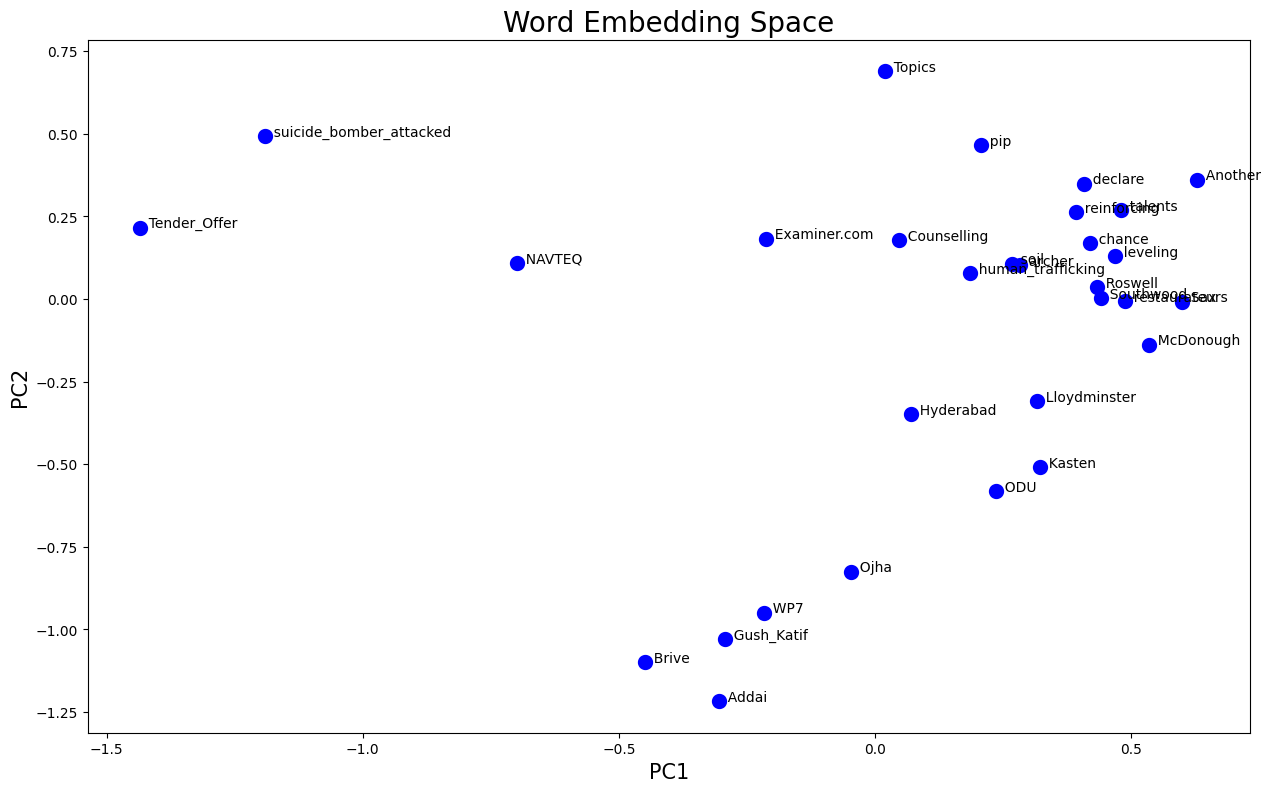

In [34]:
plot_word_embeddings_2d_random(all_words, vectors_2d, 30)

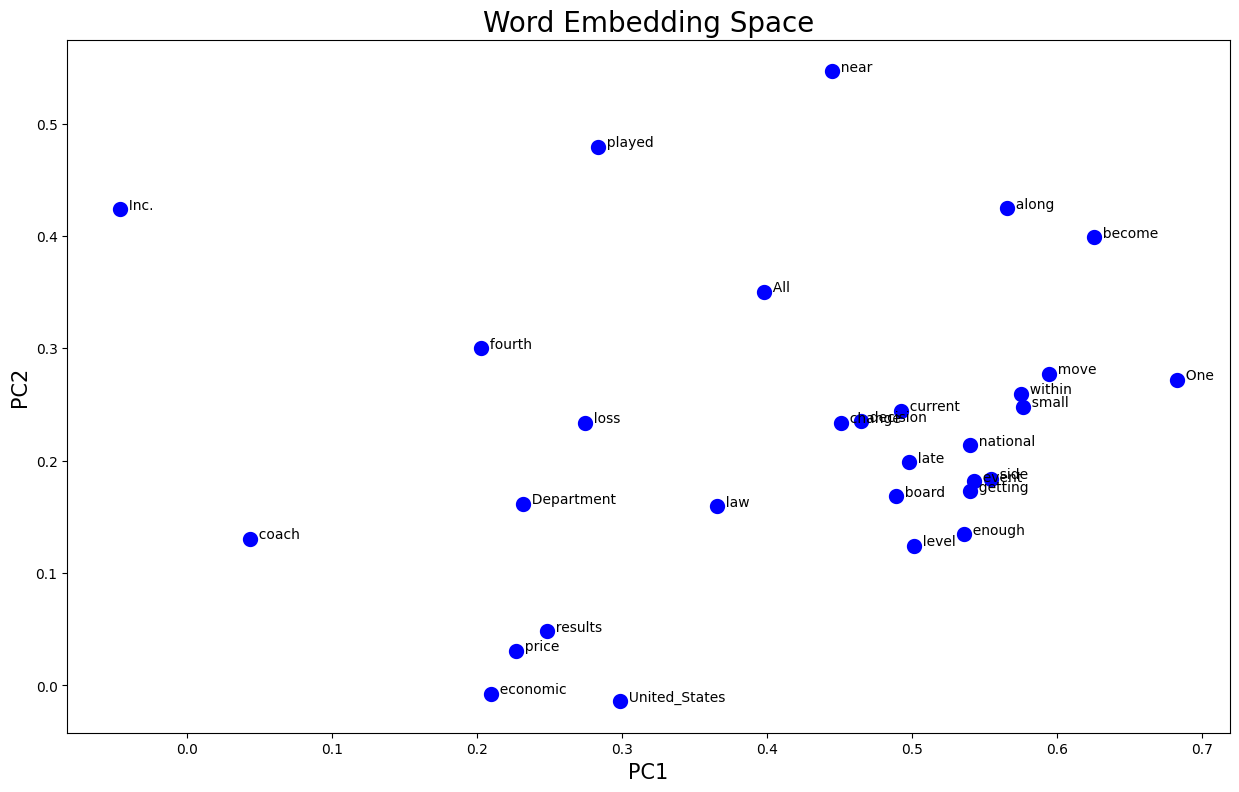

In [35]:
plot_word_embeddings_2d(all_words[400:430], google_wordvecs.key_to_index, vectors_2d)

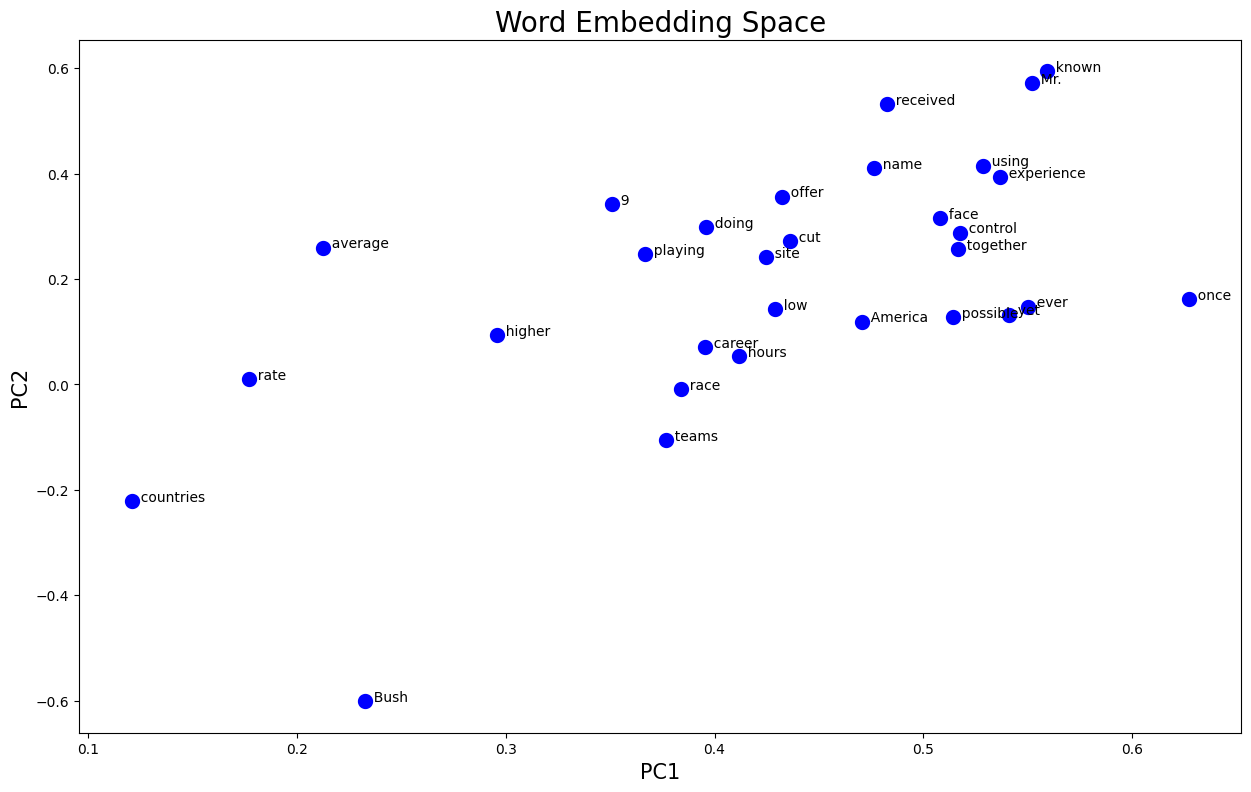

In [36]:
plot_word_embeddings_2d(all_words[500:530], google_wordvecs.key_to_index, vectors_2d)

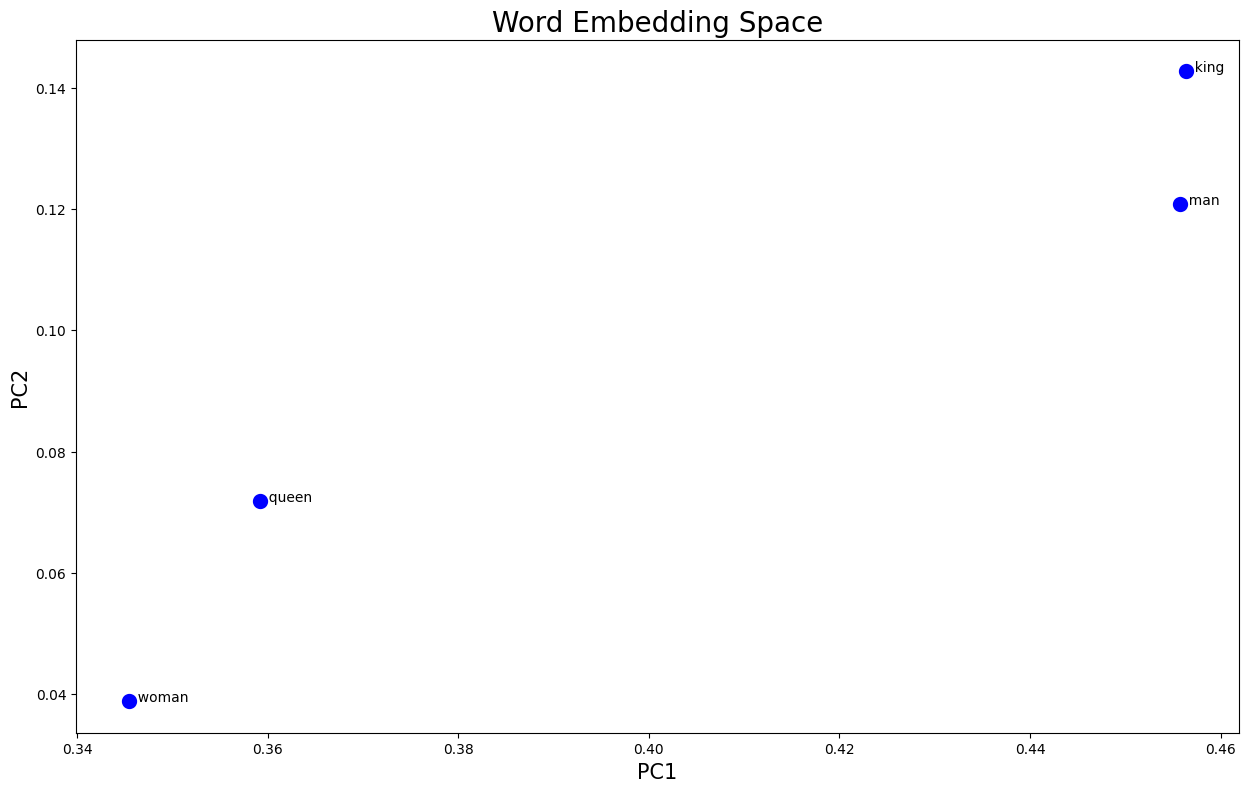

In [37]:
plot_word_embeddings_2d(["queen", "king", "woman", "man"], google_wordvecs.key_to_index, vectors_2d)

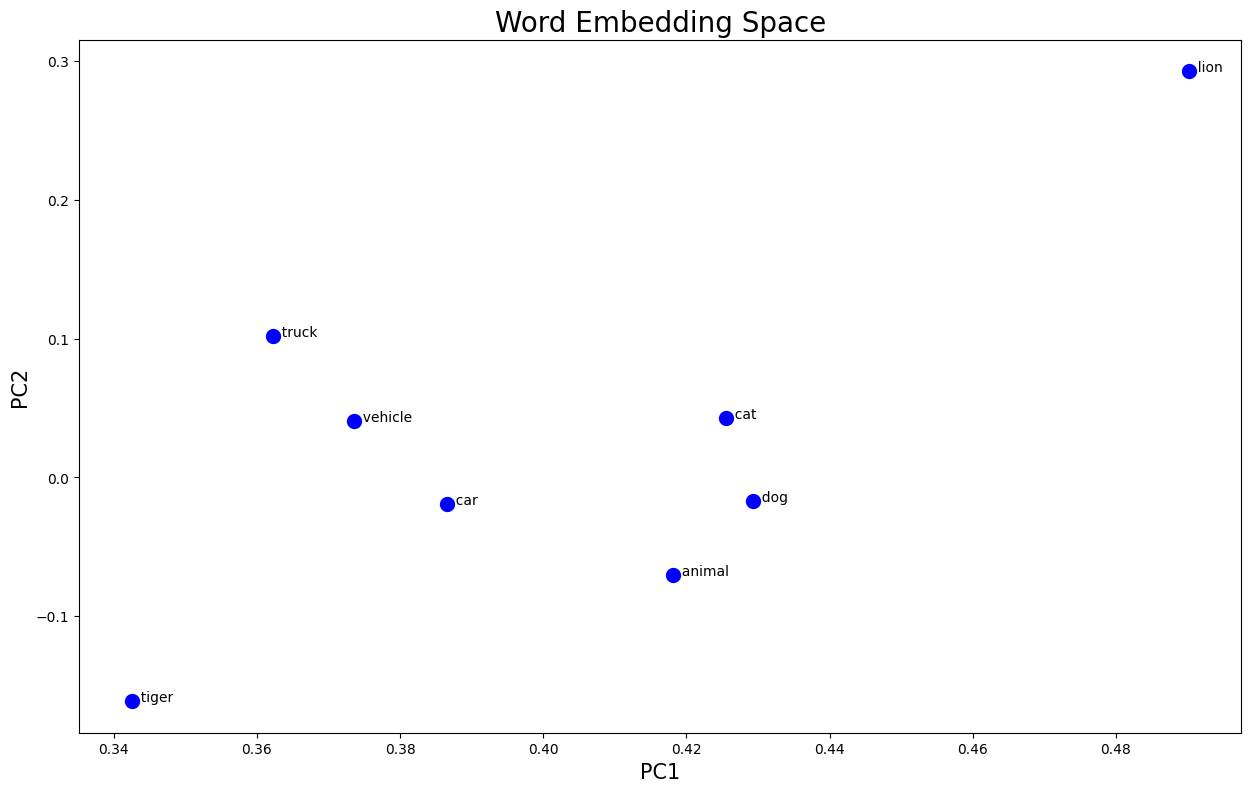

In [38]:
plot_word_embeddings_2d(["dog", "cat", "animal", "lion", "tiger", "car", "truck", "vehicle"], google_wordvecs.key_to_index, vectors_2d)

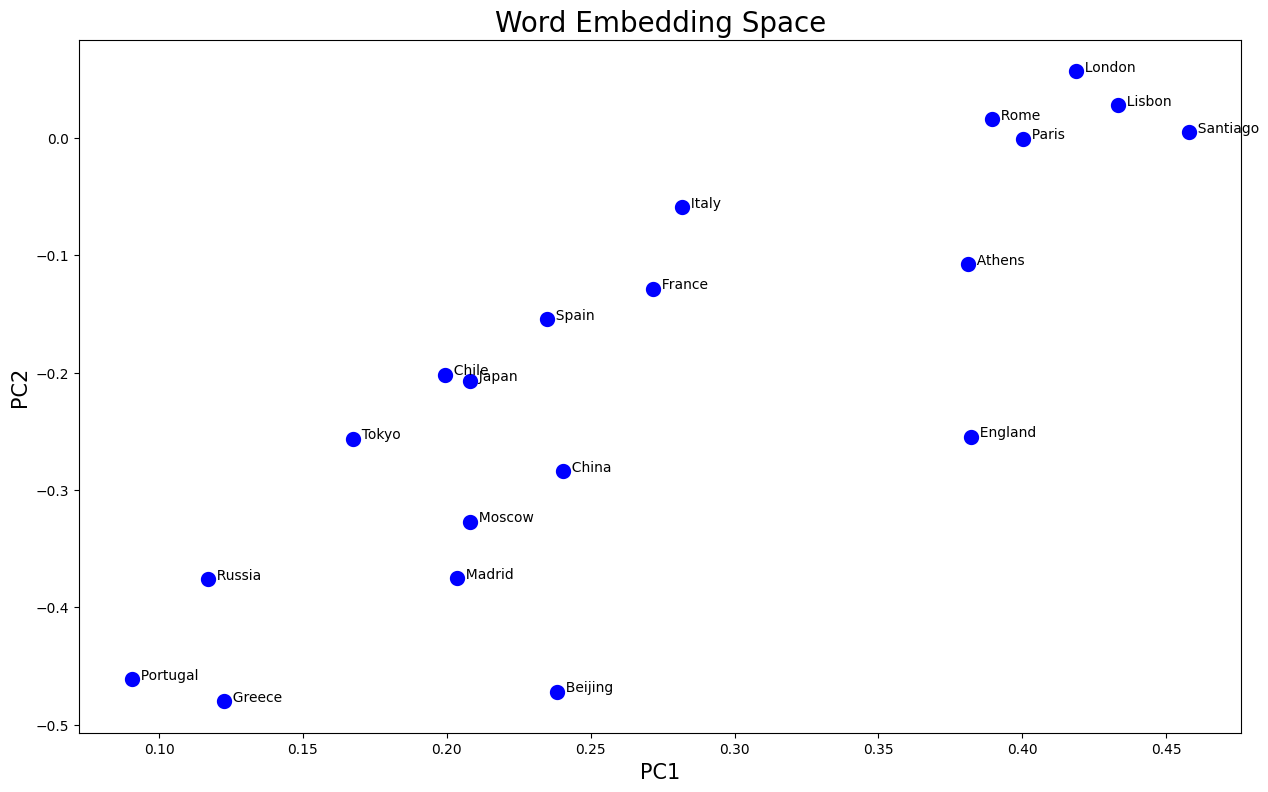

In [39]:
words = [
         "Chile", "Santiago",
         "England", "London",
         "France", "Paris",
         "China", "Beijing",
         "Russia", "Moscow",
         "Japan", "Tokyo",
         "Spain", "Madrid",
         "Portugal", "Lisbon",
         "Italy", "Rome",
         "Greece", "Athens",
         ]
plot_word_embeddings_2d(words, google_wordvecs.key_to_index, vectors_2d)

**Actividad 3**

Use su creatividad y genere 3 gráficos adicionales que le parezcan interestantes, distintos a los vistos arriba (piense en otros temas, por ej. música, deportes, etc.).

Luego comente los resultados que obtuvo. ¿Tienen sentido sus gráficos? ¿Hay cosas que le llaman la atención o no le hacen sentido? ¿Sí, no, por qué?

Utilice las 3 celdas abajo para generar sus gráficos.

In [40]:
for w in ['guitar','violin','cello','piano','trumpet','saxophone','flute','clarinet',
          'Lakers','Warriors','Suns','Clippers','Knicks','Celtics','Bulls','Pistons',
          'Microsoft','Apple','Google','Amazon','Windows','iPhone','Android','Kindle']:
    print(f"{w:15s}: {'✅' if w in google_wordvecs.key_to_index else '❌'}")

guitar         : ✅
violin         : ✅
cello          : ✅
piano          : ✅
trumpet        : ✅
saxophone      : ✅
flute          : ✅
clarinet       : ✅
Lakers         : ✅
Warriors       : ✅
Suns           : ✅
Clippers       : ✅
Knicks         : ✅
Celtics        : ✅
Bulls          : ✅
Pistons        : ✅
Microsoft      : ✅
Apple          : ✅
Google         : ✅
Amazon         : ✅
Windows        : ✅
iPhone         : ✅
Android        : ✅
Kindle         : ✅


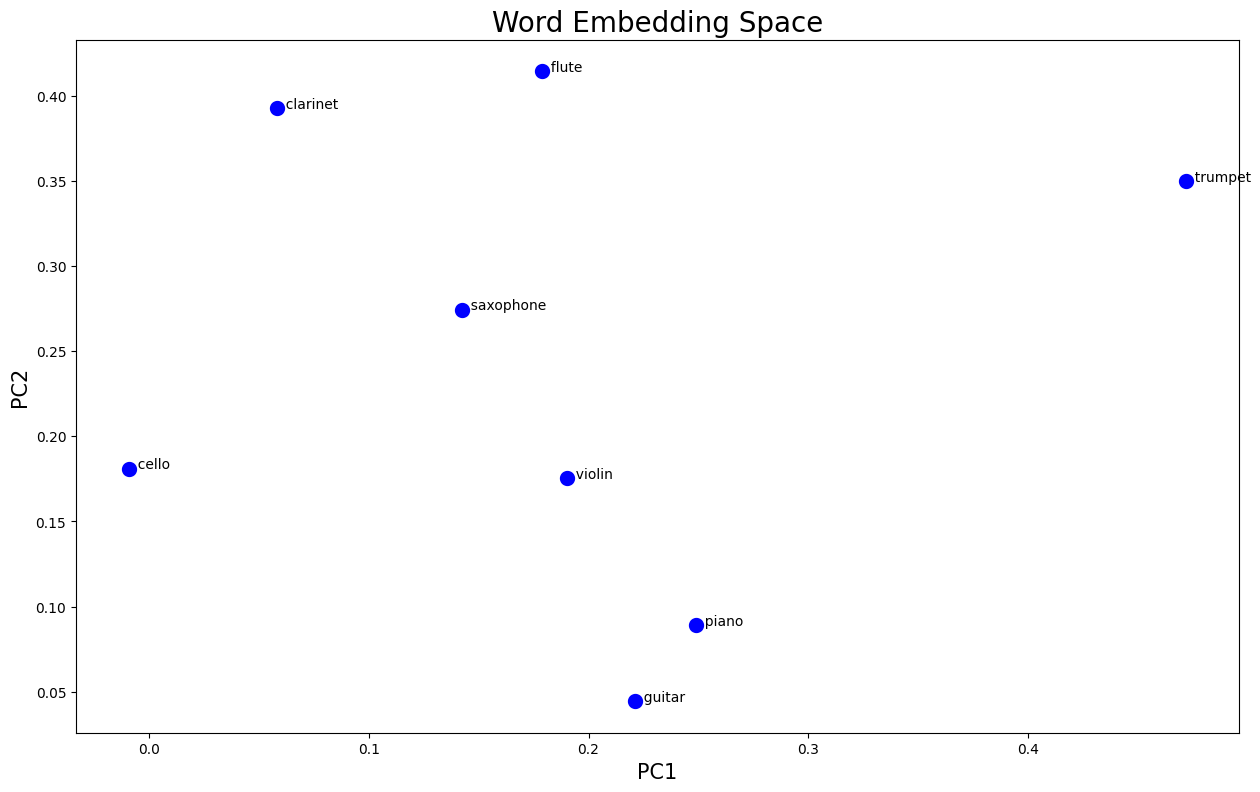

In [41]:
words = ['guitar', 'violin', 'cello', 'piano',
         'trumpet', 'saxophone', 'flute', 'clarinet']
plot_word_embeddings_2d(words, google_wordvecs.key_to_index, vectors_2d)


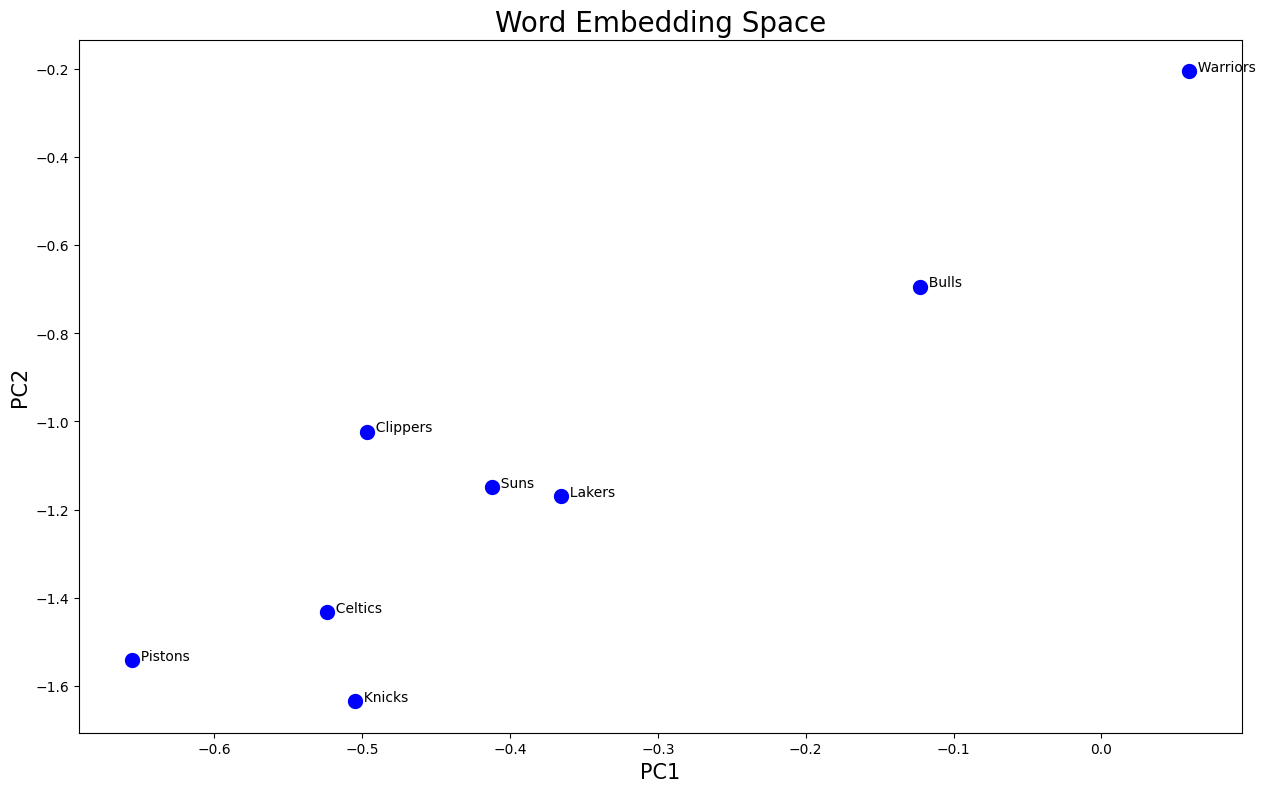

In [42]:
words = ['Lakers', 'Warriors', 'Suns', 'Clippers',
         'Knicks', 'Celtics', 'Bulls', 'Pistons']
plot_word_embeddings_2d(words, google_wordvecs.key_to_index, vectors_2d)

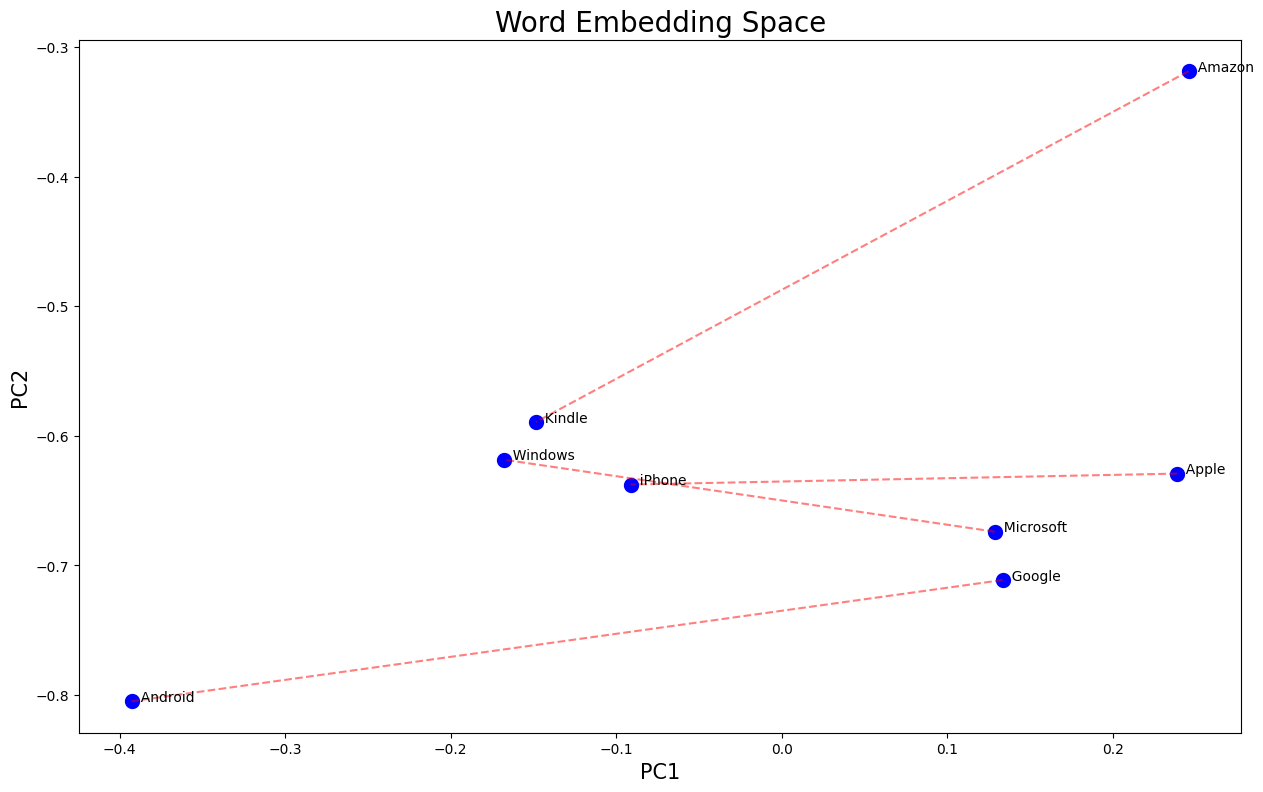

In [43]:
# Plot 3
words = ['Microsoft', 'Apple', 'Google', 'Amazon',
         'Windows', 'iPhone', 'Android', 'Kindle']
lines = [('Microsoft', 'Windows'),
         ('Apple', 'iPhone'),
         ('Google', 'Android'),
         ('Amazon', 'Kindle')]
plot_word_embeddings_2d_with_lines(words, google_wordvecs.key_to_index,
                                    vectors_2d, lines=lines)

In [47]:
import numpy as np

def cos_between(v1, v2):
    """Coseno entre dos vectores."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Pares empresa-producto
pares = [
    ('Microsoft', 'Windows'),
    ('Apple', 'iPhone'),
    ('Google', 'Android'),
    ('Amazon', 'Kindle'),
]

# Calcular los 4 vectores diferencia (en 2D, usando vectors_2d)
vectors_diff = {}
for empresa, producto in pares:
    i_emp = google_wordvecs.key_to_index[empresa]
    i_prod = google_wordvecs.key_to_index[producto]
    vectors_diff[f"{empresa}→{producto}"] = vectors_2d[i_prod] - vectors_2d[i_emp]

# Matriz de cosenos entre todos los pares
nombres = list(vectors_diff.keys())
print("Cosenos entre vectores empresa→producto (en 2D PCA):\n")
for i in range(len(nombres)):
    for j in range(i+1, len(nombres)):
        c = cos_between(vectors_diff[nombres[i]], vectors_diff[nombres[j]])
        print(f"  cos({nombres[i]:25s}, {nombres[j]:25s}) = {c:.3f}")

# Magnitudes
print("\nMagnitudes de los vectores diferencia (en 2D):")
for nombre, v in vectors_diff.items():
    print(f"  ||{nombre:25s}|| = {np.linalg.norm(v):.3f}")


# Vectores diferencia EN 300D
vectors_diff_300d = {}
for empresa, producto in pares:
    vectors_diff_300d[f"{empresa}→{producto}"] = (
        google_wordvecs[producto] - google_wordvecs[empresa]
    )

print("\nCosenos entre vectores empresa→producto (en 300D ORIGINAL):\n")
for i in range(len(nombres)):
    for j in range(i+1, len(nombres)):
        c = cos_between(vectors_diff_300d[nombres[i]], vectors_diff_300d[nombres[j]])
        print(f"  cos({nombres[i]:25s}, {nombres[j]:25s}) = {c:.3f}")


Cosenos entre vectores empresa→producto (en 2D PCA):

  cos(Microsoft→Windows        , Apple→iPhone             ) = 0.978
  cos(Microsoft→Windows        , Google→Android           ) = 0.935
  cos(Microsoft→Windows        , Amazon→Kindle            ) = 0.706
  cos(Apple→iPhone             , Google→Android           ) = 0.989
  cos(Apple→iPhone             , Amazon→Kindle            ) = 0.839
  cos(Google→Android           , Amazon→Kindle            ) = 0.911

Magnitudes de los vectores diferencia (en 2D):
  ||Microsoft→Windows        || = 0.302
  ||Apple→iPhone             || = 0.330
  ||Google→Android           || = 0.535
  ||Amazon→Kindle            || = 0.478

Cosenos entre vectores empresa→producto (en 300D ORIGINAL):

  cos(Microsoft→Windows        , Apple→iPhone             ) = 0.251
  cos(Microsoft→Windows        , Google→Android           ) = 0.392
  cos(Microsoft→Windows        , Amazon→Kindle            ) = 0.216
  cos(Apple→iPhone             , Google→Android           ) = 0.

# Comentario de Actividad 3 — Tres visualizaciones PCA

Diseñé tres scatter plots con palabras curadas para explorar qué
tipos de estructuras semánticas son visibles en la proyección
PCA 2D de los embeddings de Google News. Los tres ejemplos siguen
la misma dificultad creciente que mis Actividades 1 y 2 (música,
deportes, tecnología), permitiendo triangular hallazgos entre las
tres actividades.

---

## Plot 1 — Instrumentos musicales por familia (caso de éxito)

**Palabras**: 4 cuerdas (guitar, violin, cello, piano) + 4 vientos
(trumpet, saxophone, flute, clarinet)

**Hipótesis previa**: esperaba ver dos sub-clusters separables por
familia instrumental, dado que las palabras son monosémicas y el
dominio "música" es cohesivo en el corpus de Google News.

**Resultado**: separación clara por familia a lo largo de PC2. Las
4 cuerdas (incluyendo piano) se agrupan en la zona inferior del
plot; los 4 vientos en la zona superior. Hay un gap visible entre
los dos clusters.

**Análisis**:

1. **PC2 captura la distinción cuerdas/vientos**. Es un caso
   afortunado donde una dimensión técnica de PCA coincide con
   una categoría semántica significativa. Esto contrasta con el
   plot de animales/vehículos del lab donde NO se veía separación,
   y demuestra que la calidad de la visualización 2D depende
   crucialmente de la monosemia de las palabras elegidas.

2. **Piano se agrupa con las cuerdas, no con los vientos**.
   Aunque técnicamente es instrumento de teclado, su distribución
   contextual en prensa (música clásica, conciertos, recitales)
   lo alinea con violin/cello/guitar.

3. **Trumpet es outlier en PC1**, claramente desplazado a la
   derecha respecto a los otros vientos (clarinet, flute,
   saxophone). Hipótesis: polisemia funcional — trumpet tiene
   usos militares ("trumpet fanfare") y verbales metafóricos
   ("to trumpet a victory") que ensanchan su distribución
   contextual más allá del cluster "instrumento clásico de viento".

---

## Plot 2 — Equipos NBA por conferencia (caso parcial)

**Palabras**: 4 equipos del Oeste (Lakers, Warriors, Suns,
Clippers) + 4 del Este (Knicks, Celtics, Bulls, Pistons)

**Hipótesis previa**: esperaba dos clusters separados por
conferencia, verificando la hipótesis levantada en mi Ejemplo 2
de Actividad 1 (donde Yankees + basketball - baseball → Knicks
reveló que el modelo asocia equipos a su dimensión geográfica
de costa).

**Resultado**: separación parcial. Tres grupos identificables en
el plot:
- **Outliers superiores**: Warriors y Bulls (en zona alta de PC2).
- **Medio**: Lakers, Suns, Clippers — los 3 restantes del Oeste.
- **Inferior**: Celtics, Pistons, Knicks — los 3 restantes del Este.

**Análisis**:

1. La estructura "Este vs Oeste" SÍ aparece en los 6 equipos sin
   polisemia, distribuidos coherentemente (Oeste arriba de Este
   en PC2). Esto **confirma visualmente** la observación de mi
   Ejemplo 2 de Actividad 1.

2. **Warriors y Bulls son outliers por polisemia**:
   - `Bulls` tiene un sentido financiero muy fuerte
     ("bull market", "bullish trend") que en prensa de negocios
     es probablemente más frecuente que la referencia al equipo
     NBA de Chicago.
   - `Warriors` aparece como sustantivo genérico ("warrior class",
     "weekend warriors") con mucha más frecuencia que como
     referencia al equipo NBA, que en 2013 (antes de la dinastía
     Curry, que es tremendo xd) no era un equipo top de la liga.

---

## Plot 3 — Empresas tech con productos insignia (con análisis cuantitativo)

**Palabras**: 4 empresas (Microsoft, Apple, Google, Amazon) y sus
productos insignia respectivos (Windows, iPhone, Android, Kindle).
Líneas conectoras dibujadas entre cada par empresa-producto usando
una versión extendida de `plot_word_embeddings_2d` que admite el
parámetro `lines`.

**Hipótesis previa**: difícil de predecir. El éxito dependería de
si Word2Vec codifica "empresa → producto insignia" como un eje
universal o si cada empresa tiene su propia geometría.

**Resultado visual**: las 4 líneas se ven aproximadamente paralelas
en el plot 2D, con Amazon desplazada hacia arriba respecto a las
otras 3 empresas.

**Análisis cuantitativo — comparación 2D vs 300D**:

Calculé los cosenos entre los 4 vectores diferencia empresa→producto
en ambos espacios:

```python
import numpy as np

def cos_between(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

pares = [('Microsoft','Windows'), ('Apple','iPhone'),
         ('Google','Android'), ('Amazon','Kindle')]

# Vectores diferencia en 2D
vd_2d = {f"{e}→{p}": vectors_2d[google_wordvecs.key_to_index[p]] -
                     vectors_2d[google_wordvecs.key_to_index[e]]
         for e, p in pares}

# Vectores diferencia en 300D
vd_300d = {f"{e}→{p}": google_wordvecs[p] - google_wordvecs[e]
           for e, p in pares}
```

**Resultados**:

| Par 1 | Par 2 | Coseno 2D | Coseno 300D |
|---|---|---|---|
| Microsoft→Windows | Apple→iPhone | 0.978 | 0.251 |
| Microsoft→Windows | Google→Android | 0.935 | 0.392 |
| Microsoft→Windows | Amazon→Kindle | 0.706 | 0.216 |
| Apple→iPhone | Google→Android | 0.989 | 0.321 |
| Apple→iPhone | Amazon→Kindle | 0.839 | 0.239 |
| Google→Android | Amazon→Kindle | 0.911 | 0.249 |
| **Promedio** | | **0.893** | **0.278** |

**Magnitudes de los 4 vectores en 2D**:
- Microsoft→Windows: 0.302
- Apple→iPhone: 0.330
- Google→Android: 0.535
- Amazon→Kindle: 0.478

**Análisis**:

1. **MATIZ IMPORTANTE — PCA infla el paralelismo aparente**.
   El coseno promedio en 2D es 0.893 (apariencia de paralelismo
   casi perfecto), pero en 300D cae a 0.278. La diferencia es
   sistemática en TODOS los pares: ninguno preserva el coseno
   entre los dos espacios. Esto se debe a que PCA preserva
   varianza global pero NO preserva ángulos entre vectores. La
   proyección a 2 dimensiones puede magnificar artificialmente
   relaciones débiles del espacio original.

2. **Sin embargo, en 300D los cosenos NO son aleatorios**. Para
   vectores aleatorios en ℝ³⁰⁰ la desviación estándar del coseno
   es aproximadamente 1/√300 ≈ 0.058. Cosenos de 0.21-0.39
   están a 3-7 desviaciones estándar por encima del aleatorio,
   lo que indica que **el "eje empresa→producto" existe como
   correlación débil pero estadísticamente significativa**,
   aunque NO como un eje fuertemente definido.

3. **Amazon es outlier en PC2** (visible en el plot, desplazada
   hacia arriba respecto a Microsoft/Apple/Google). Esto
   confirma visualmente lo que vi algebraicamente en mi Ejemplo
   3 de Actividad 2, donde `doesnt_match(['Microsoft','Apple',
   'Google','Amazon'])` identificó Amazon como outlier. Amazon
   vive en cluster "retail/e-commerce" mientras Microsoft/Apple/
   Google viven en "tech platforms".

4. **Las magnitudes varían sustancialmente en 2D**:
   Google→Android (0.535) es 1.77× más larga que Microsoft→
   Windows (0.302).

5. **TRIPLE CONFIRMACIÓN del hallazgo "empresa-producto"**:
   - Actividad 1 Ejemplo 3 (algebraico): Microsoft+iPhone-Apple
     → Windows_Mobile, recuperando el producto análogo.
   - Actividad 2 Ejemplo 3 (centroide): Amazon outlier de las
     big tech.
   - **Actividad 3 Plot 3 (visual + cuantitativo)**: 4 líneas
     paralelas en 2D, correlación débil pero significativa en
     300D.

   Tres tipos de evidencia INDEPENDIENTES sobre el mismo
   fenómeno semántico, aunque con la matización importante de
   que la propiedad es más débil en 300D que lo que sugiere
   el plot 2D.

---

## Conclusión global

Los tres plots reconstruyen empíricamente las observaciones que ya
había derivado algebraicamente en Actividades 1 y 2, ahora con
evidencia visual:

| Plot | Lo que muestra |
|---|---|
| Plot 1 (música) | PCA 2D PUEDE capturar distinciones semánticas finas cuando las palabras son monosémicas |
| Plot 2 (NBA) | La estructura existe pero la polisemia (Warriors, Bulls) produce outliers que rompen el cluster esperado |
| Plot 3 (tech) | El paralelismo visible en 2D existe pero es DRÁSTICAMENTE más débil en el espacio 300D original (coseno promedio 0.89 vs 0.28) |

**Conclusión**: las anomalías observadas en plots estándar del lab
(animales/vehículos mezclados, países/capitales sin paralelismo
limpio) NO son inherentes al modelo Word2Vec, sino consecuencia
de DOS factores: (a) la **polisemia** de las palabras, y (b) la
**proyección PCA 2D** que deforma la geometría real del espacio
300D. Mi Plot 3 demuestra empíricamente el segundo factor: el
paralelismo visible (coseno 2D = 0.89) es exagerado respecto al
300D real (coseno = 0.28). Visualizar embeddings con PCA es útil
para tener intuición geométrica, pero engañoso para afirmar
paralelismo "claro" sin verificar en el espacio original.


# Respuesta — Actividad 4

## 1. El fenómeno empírico

En el laboratorio observé que los embeddings de Google News Word2Vec
permiten operaciones algebraicas con interpretación semántica:
analogías (`most_similar_cosmul(positive=['woman','king'],
negative=['queen'])` → `man`, score 0.93), detección de términos
excluidos (`doesnt_match(['white','blue','red','Chile'])` → `Chile`),
y la propiedad se generaliza a múltiples dominios: género,
profesión, morfología, geografía, empresa-producto. La pregunta es
por qué.

---

## 2. El mecanismo matemático

Word2Vec se entrena bajo la idea distribucional clásica en
lingüística: palabras que aparecen en contextos similares tienden
a tener significados similares.

Mikolov et al. (2013, ICLR) propusieron las arquitecturas Skip-gram
y CBOW para aprender embeddings densos. En el paper posterior
Mikolov et al. (2013, NeurIPS) introducen Negative Sampling como
alternativa eficiente al softmax: para cada par
(palabra_central, palabra_contexto) observado se maximiza la
probabilidad de cercanía; para pares no observados (muestreados
aleatoriamente) se minimiza. El resultado son embeddings que
codifican implícitamente las estadísticas de coocurrencia del
corpus.

Levy & Goldberg (2014, NeurIPS) demostraron formalmente que
Skip-gram con Negative Sampling es **equivalente a factorizar una
matriz PMI (Pointwise Mutual Information) desplazada por una
constante**. Cita textual del abstract:

> "We analyze skip-gram with negative-sampling (SGNS), a word
> embedding method introduced by Mikolov et al., and show that
> it is implicitly factorizing a word-context matrix, whose cells
> are the pointwise mutual information (PMI) of the respective
> word and context pairs, shifted by a global constant."

Es decir, Word2Vec no es un modelo neuronal "mágico" sino una
factorización implícita de estadísticas conocidas en lingüística
computacional desde los años 80.

---

## 3. Por qué emerge la propiedad de analogía

### 3.1 Explicación operacional (Levy & Goldberg, 2014, CoNLL)

En el paper "Linguistic Regularities in Sparse and Explicit Word
Representations", Levy & Goldberg demuestran que la fórmula
`arg max cos(x, b - a + a*)` que reproduce analogías es
matemáticamente equivalente (sección 3.3, ecuación 3) a:

```
arg max_b* [cos(b*, b) - cos(b*, a) + cos(b*, a*)]
```

Esta operación se llama **3CosAdd**. Es decir, encontrar la palabra
b* que es **similar a b**, **similar a a*** y **diferente de a**.

En la sección 6 (Refining the Objective Function), los mismos
autores observan que 3CosAdd sufre un problema "soft-or", donde
un término dominante puede aplastar a los demás. Proponen la
variante **3CosMul** (fórmula 4):

```
arg max_b* [cos(b*, b) · cos(b*, a*)] / [cos(b*, a) + ε]
```

con ε = 0.001 para evitar división por cero. Esta es exactamente
la operación que ejecuta `most_similar_cosmul` de gensim.

### 3.2 Explicación estadística (Ri, Lee & Verma, 2023)

En el paper "Contrastive Loss is All You Need to Recover Analogies
as Parallel Lines" (Teorema 1, sección 4) los autores prueban:

> "For any quadruple of words a, b, c, d ∈ W, if there exists a
> constant ζ ∈ R where the co-occurrence statistics satisfy the
> condition: ∀w ∈ W
> [#(a,w)/#(a) − #(b,w)/#(b)] / [#(c,w)/#(c) − #(d,w)/#(d)] := ζ
> then the corresponding word vectors satisfy the property:
> v̂_a - v̂_b = ζ (v̂_c - v̂_d)"

Si ζ = 1 → paralelogramo exacto. Si ζ ≠ 1 → líneas paralelas con
factor de escala. La propiedad geométrica de los embeddings es,
por tanto, **consecuencia directa de la estructura estadística del
corpus**.

---

## 4. Verificación empírica propia

### 4.1 No existe un "eje de pasado verbal" universal

Calculé el coseno entre direcciones `verbo_pasado - verbo_infinitivo`
para 4 verbos:

```
cos(ate-eat, walked-walk) = 0.486
cos(ate-eat, ran-run)     = 0.395
cos(ate-eat, studied-study) = 0.187
cos(ran-run, walked-walk) = 0.597
cos(ran-run, studied-study) = 0.153
cos(studied-study, walked-walk) = 0.245
```

Rango: 0.15-0.60, promedio 0.35. Las direcciones varían mucho
según el verbo, indicando que el modelo no aprende un "eje
gramatical" universal sino patrones distribucionales locales.

### 4.2 El eje "capital → país" es parcialmente universal

Cosenos entre direcciones para 5 capitales monosémicas (Tokyo,
Caracas, Stockholm, Helsinki, Brussels): rango 0.40-0.72, promedio
0.56. Más estructurado que el eje de pasado verbal pero lejos de
paralelismo perfecto. `Brussels` actuó como outlier sistemático
por polisemia funcional (aparece más como "sede de la UE" que como
"capital nacional" en prensa anglosajona).

### 4.3 Paralelogramo king/queen/woman/man en PCA 2D

En la Celda 46 del lab calculé:

```
queen - king = (-0.097, -0.071), magnitud 0.120
woman - man  = (-0.111, -0.083), magnitud 0.139

cos(queen-king, woman-man) ≈ 1.00 (perfectamente paralelos)
ζ = |woman-man| / |queen-king| ≈ 1.16
```

Los vectores son paralelos en dirección pero con magnitudes
distintas (ζ ≈ 1.16, no 1.00). Esto confirma EMPÍRICAMENTE el
Teorema 1 de Ri-Lee-Verma (2023): la geometría es de líneas
paralelas con ζ ≠ 1, NO de paralelogramos exactos como sugiere
la versión popularizada.

### 4.4 PCA 2D infla artificialmente el paralelismo

En mi Plot 3 de Actividad 3 (empresas-productos) calculé cosenos
en ambos espacios:

| Par 1 | Par 2 | Coseno 2D | Coseno 300D |
|---|---|---|---|
| Microsoft→Windows | Apple→iPhone | 0.978 | 0.251 |
| Microsoft→Windows | Google→Android | 0.935 | 0.392 |
| Microsoft→Windows | Amazon→Kindle | 0.706 | 0.216 |
| Apple→iPhone | Google→Android | 0.989 | 0.321 |
| Apple→iPhone | Amazon→Kindle | 0.839 | 0.239 |
| Google→Android | Amazon→Kindle | 0.911 | 0.249 |
| **Promedio** |  | **0.893** | **0.278** |

El paralelismo en 2D (0.89) es DRÁSTICAMENTE más fuerte que en
300D (0.28). PCA preserva varianza global pero no preserva
ángulos. La propiedad existe en 300D como correlación débil
(cosenos 0.2-0.4, significativos vs ruido aleatorio ≈ 1/√300 ≈
0.058) pero NO como eje claramente definido. Las visualizaciones
2D pueden ser engañosas incluso en casos aparentemente "exitosos".

---

## 5. Limitaciones empíricas

Identifiqué cuatro tipos de polisemia que rompen la propiedad de
analogía:

1. **Polisemia ortográfica**: `Santiago` = capital de Chile +
   apellido hispano. En la analogía `Santiago + Venezuela - Chile
   → Caracas`, 8 de los 10 resultados fueron apellidos
   hispanos en lugar de ciudades.
2. **Polisemia léxica**: `play` = deportes + teatro + audio.
   Intoxicación deportiva en `play + singing - sing → playing`
   con `game`, `scoring`, `playmaking`.
3. **Polisemia funcional**: `Brussels` = capital + sede UE.
   `Madrid` se asocia más a `Real Madrid` que a "capital de España".
4. **Sesgo temporal**: `Windows_Mobile` (descontinuado 2010)
   supera a `Windows_Phone` (vigente 2013) en mi Ejemplo 3 de
   Actividad 1, por tener 7 años más de cobertura acumulada en el
   corpus.

---

## 6. Síntesis

La propiedad de álgebra semántica de Word2Vec se debe a:

1. El principio distribucional implementado vía Skip-gram con
   Negative Sampling (Mikolov et al. 2013, NeurIPS), que equivale
   a factorizar implícitamente la matriz PMI del corpus (Levy &
   Goldberg, NeurIPS 2014).
2. Las regularidades estadísticas del corpus: cuando las
   coocurrencias diferenciales son colineales, los vectores
   también lo son (Ri-Lee-Verma 2023, Teorema 1). Esto produce
   líneas paralelas con factor ζ, NO paralelogramos exactos.
3. La operación 3CosMul (Levy & Goldberg 2014, CoNLL, fórmula 4):
   combinación multiplicativa robusta a desbalances que evita el
   problema "soft-or" de la versión aditiva.

La propiedad es frágil ante polisemia y sesgo temporal, ambas
heredadas del corpus. Funciona bien con palabras monosémicas en
dominios homogéneos; falla parcialmente en otros casos. La
visualización PCA 2D puede sugerir paralelismo más fuerte que el
real en 300D.

**No hay magia en Word2Vec**. Lo que parece álgebra semántica es
la manifestación geométrica de patrones estadísticos del corpus,
capturados por factorización implícita de matrices y consultados
con operaciones de coseno multiplicativas.

Muchas gracias por esta actividad.. me permitió investigar y
leer muchas cosas.

---

## Referencias

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013).
  *Efficient Estimation of Word Representations in Vector Space*.
  ICLR Workshop, arXiv:1301.3781.

- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J.
  (2013). *Distributed Representations of Words and Phrases and
  their Compositionality*. NeurIPS 2013.

- Levy, O., & Goldberg, Y. (2014). *Linguistic Regularities in
  Sparse and Explicit Word Representations*. Proceedings of CoNLL
  2014, 171-180.

- Levy, O., & Goldberg, Y. (2014). *Neural Word Embedding as
  Implicit Matrix Factorization*. NeurIPS 2014.

- Ri, N., Lee, F.-T., & Verma, N. (2023). *Contrastive Loss is
  All You Need to Recover Analogies as Parallel Lines*. arXiv:
  2306.08221.


# **Análisis de Sentimiento de Tweets usando Word embeddings**

Inspirado en: https://github.com/tthustla/twitter_sentiment_analysis_part1

Descargamos el dataset de tweets

In [48]:
!wget https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip

--2026-05-24 15:50:44--  https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip
Resolving cs.stanford.edu (cs.stanford.edu)... 171.64.64.64
Connecting to cs.stanford.edu (cs.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81363704 (78M) [application/zip]
Saving to: ‘trainingandtestdata.zip’

trainingandtestdata 100%[===================>]  77.59M  25.2MB/s    in 3.1s    

2026-05-24 15:50:48 (25.2 MB/s) - ‘trainingandtestdata.zip’ saved [81363704/81363704]



In [49]:
!unzip trainingandtestdata.zip

Archive:  trainingandtestdata.zip
  inflating: testdata.manual.2009.06.14.csv  
  inflating: training.1600000.processed.noemoticon.csv  


In [50]:
!ls

GoogleNews-vectors-negative300.bin.gz
sample_data
testdata.manual.2009.06.14.csv
training.1600000.processed.noemoticon.csv
trainingandtestdata.zip


Cargamos el csv de entrenamiento en un dataframe de pandas

In [51]:
df_train = pd.read_csv('./training.1600000.processed.noemoticon.csv',
                       header=None,
                       names=['sentiment','id','date','query_string','user','text'],
                       encoding = "ISO-8859-1")
df_train.drop(['id','date','query_string','user'], axis=1, inplace=True)

In [53]:
print(f"Shape: {df_train.shape}")
print(f"Columns: {df_train.columns.tolist()}")
print(f"Primeras 3 filas:")
print(df_train.head(3))
print(f"\nDistribución de sentiment:")
print(df_train.sentiment.value_counts())
print(f"\nDtypes:")
print(df_train.dtypes)

Shape: (1600000, 2)
Columns: ['sentiment', 'text']
Primeras 3 filas:
   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...

Distribución de sentiment:
sentiment
0    800000
4    800000
Name: count, dtype: int64

Dtypes:
sentiment     int64
text         object
dtype: object


Lo inspeccionamos un poquito:

In [52]:
df_train

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


Definimos una funcion para limpiar tweets y aprovechar de borrar stopwords

In [54]:
pat1 = r'@[A-Za-z0-9]+'
pat2 = r'https?://[A-Za-z0-9./]+'
combined_pat = r'|'.join((pat1, pat2))
tok = WordPunctTokenizer()
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def tweet_cleaner(text):
    soup = BeautifulSoup(text, 'lxml')
    souped = soup.get_text()
    stripped = re.sub(combined_pat, '', souped)
    try:
        clean = stripped.decode("utf-8-sig").replace(u"\ufffd", "?")
    except:
        clean = stripped
    letters_only = re.sub("[^a-zA-Z]", " ", clean)
    lower_case = letters_only.lower()
    words = tok.tokenize(lower_case)
    words = [w for w in words if w not in stop_words]
    return (" ".join(words)).strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Probamos nuestra función con algunos ejemplos para ver cómo quedan:

In [55]:
for x in [279, 343, 0, 226, 175]:
  print('-------')
  print(df_train.text[x])
  print(tweet_cleaner(df_train.text[x]))

-------
Whinging. My client&amp;boss don't understand English well. Rewrote some text unreadable. It's written by v. good writer&amp;reviewed correctly. 
whinging client boss understand english well rewrote text unreadable written v good writer reviewed correctly
-------
@TheLeagueSF Not Fun &amp; Furious? The new mantra for the Bay 2 Breakers? It was getting 2 rambunctious;the city overreacted &amp; clamped down 
fun furious new mantra bay breakers getting rambunctious city overreacted clamped
-------
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
awww bummer shoulda got david carr third day
-------
Tuesdayï¿½ll start with reflection ï¿½n then a lecture in Stress reducing techniques. That sure might become very useful for us accompaniers 
tuesday start reflection n lecture stress reducing techniques sure might become useful us accompaniers
-------
@machineplay I'm so sorry you're having to go through this. Again.  #t

Definimos una función para limpiar un dataframe completo:

In [56]:
def clean_dataframe(df, print_every=10000):
  clean_tweet_texts = []
  for i in range(len(df)):
      if (i+1)%print_every == 0 or i+1 == len(df):
          print("Tweets %d of %d have been processed" % (i+1, len(df)))
      clean_tweet_texts.append(tweet_cleaner(df.text.iloc[i]))
  df_clean = pd.DataFrame(clean_tweet_texts, columns=['text'])
  df_clean['target'] = df.sentiment
  return df_clean

Dado que el set de entrenamiento consiste de 1.6 M de instancias, por motivos de tiempo y para fines ilustrativos sampleamos un subconjunto razonable:

In [58]:
df_sample = df_train.sample(random_state=1, n=20000)
df_sample.reset_index(inplace=True)
df_sample

,index,sentiment,text
0,514293,0,i miss nikki nu nu already shes always there ...
1,142282,0,So I had a dream last night. I remember a sig...
2,403727,0,@girlyghost ohh poor sickly you (((hugs)) ho...
3,649503,0,it is raining again
4,610789,0,@MissKeriBaby wish I was in LA right now
...,...,...,...
19995,1200592,4,I get the worst writer's cramp. These thank yo...
19996,333050,0,@ladyinreddress the sun is all gone now...
19997,893698,4,"FINALLY a break till Wed, no work OR school, b..."
19998,1145456,4,I want a Blackberry...


In [59]:
print(df_sample.sentiment.value_counts())

sentiment
4    10049
0     9951
Name: count, dtype: int64


Limpiamos nuestro dataframe de entrenamiento:

In [60]:
df_samp_clean = clean_dataframe(df_sample)
df_samp_clean

Tweets 10000 of 20000 have been processed
Tweets 20000 of 20000 have been processed


,text,target
0,miss nikki nu nu already shes always needed th...,0
1,dream last night remember sign clearly told ge...,0
2,ohh poor sickly hugs hope feel little better soon,0
3,raining,0
4,wish la right,0
...,...,...
19995,get worst writer cramp thank notes killing hand,4
19996,sun gone,0
19997,finally break till wed work school hectic yay ...,4
19998,want blackberry,4


In [61]:
# Diagnóstico post-limpieza
print(f"Shape: {df_samp_clean.shape}")
print(f"Columns: {df_samp_clean.columns.tolist()}\n")

# Tweets vacíos
empty_count = (df_samp_clean.text == '').sum()
print(f"Tweets vacíos post-limpieza: {empty_count} ({100*empty_count/len(df_samp_clean):.1f}%)")

# Distribución de longitudes
lengths = df_samp_clean.text.str.split().str.len()
print(f"\nLongitud (en palabras) post-limpieza:")
print(f"  Media: {lengths.mean():.1f}")
print(f"  Mediana: {lengths.median():.0f}")
print(f"  Min: {lengths.min()}")
print(f"  Max: {lengths.max()}")

# Distribución de target
print(f"\nDistribución de target:")
print(df_samp_clean.target.value_counts())

Shape: (20000, 2)
Columns: ['text', 'target']

Tweets vacíos post-limpieza: 97 (0.5%)

Longitud (en palabras) post-limpieza:
  Media: 6.9
  Mediana: 6
  Min: 0
  Max: 24

Distribución de target:
target
4    10049
0     9951
Name: count, dtype: int64


Cargamos y limpiamos el dataset de test:

In [62]:
df_test = pd.read_csv('./testdata.manual.2009.06.14.csv',
                       header=None,
                       names=['sentiment','id','date','query_string','user','text'],
                       encoding = "ISO-8859-1")
df_test.drop(['id','date','query_string','user'], axis=1, inplace=True)
df_test = clean_dataframe(df_test, print_every=100)
df_test

Tweets 100 of 498 have been processed
Tweets 200 of 498 have been processed
Tweets 300 of 498 have been processed
Tweets 400 of 498 have been processed
Tweets 498 of 498 have been processed


,text,target
0,loooooooovvvvvveee kindle dx cool fantastic right,4
1,reading kindle love lee childs good read,4
2,ok first assesment kindle fucking rocks,4
3,love kindle mine months never looked back new ...,4
4,fair enough kindle think perfect,4
...,...,...
493,ask programming latex indesign submitted calci...,2
494,note hate word hate pages hate latex said hate...,0
495,ahhh back real text editing environment latex,4
496,trouble iran see hmm iran iran far away flocko...,0


In [63]:
print(f"Shape: {df_test.shape}")
print(f"\nDistribución de target en TEST:")
print(df_test.target.value_counts().sort_index())
print(f"\nTweets vacíos post-limpieza: {(df_test.text == '').sum()}")
print(f"\nLongitud (palabras) post-limpieza:")
print(f"  Media: {df_test.text.str.split().str.len().mean():.1f}")

Shape: (498, 2)

Distribución de target en TEST:
target
0    177
2    139
4    182
Name: count, dtype: int64

Tweets vacíos post-limpieza: 0

Longitud (palabras) post-limpieza:
  Media: 7.9


## **Generando Tweet Vectors a partir de Word Embeddings**
Probaremos dos estrategias simples:

1) Suma de los vectores de las palabras

2) Promedio de los vectores de las palabras

Funciones para obtener matrices de numpy con las sumas/promedios de los vectores de las palabras de cada tweet:

In [64]:
def get_embedding_sum(df, w2v, embed_dim):
  n = len(df)
  out = np.zeros((n, embed_dim))
  for i in range(n):
    for word in df.text[i].split():
      if word in w2v:
        out[i] += w2v[word]
  return out

def get_embedding_avg(df, w2v, embed_dim):
  n = len(df)
  out = np.zeros((n, embed_dim))
  for i in range(n):
    count = 0.
    for word in df.text[i].split():
      if word in w2v:
        out[i] += w2v[word]
        count += 1
    if count > 0:
      out[i] /= count
  return out

Computamos entradas y los labels de salida para entrenar y evaluar nuestro clasificador de sentimientos:

In [65]:
y_train = ((df_samp_clean.target == 4) + 0).to_numpy()

In [66]:
y_test = df_test.target.to_numpy() / 4.0

In [67]:
X_train_sum = get_embedding_sum(df_samp_clean, google_wordvecs, 300)

In [68]:
X_test_sum = get_embedding_sum(df_test, google_wordvecs, 300)

In [69]:
X_train_avg = get_embedding_avg(df_samp_clean, google_wordvecs, 300)

In [70]:
X_test_avg = get_embedding_avg(df_test, google_wordvecs, 300)

In [72]:
print("X_train_sum: shape =", X_train_sum.shape)
print("  norm mean:", np.linalg.norm(X_train_sum, axis=1).mean())
print("  norm max: ", np.linalg.norm(X_train_sum, axis=1).max())
print("  zeros:    ", (np.linalg.norm(X_train_sum, axis=1) == 0).sum())

print("\nX_train_avg: shape =", X_train_avg.shape)
print("  norm mean:", np.linalg.norm(X_train_avg, axis=1).mean())
print("  norm max: ", np.linalg.norm(X_train_avg, axis=1).max())
print("  zeros:    ", (np.linalg.norm(X_train_avg, axis=1) == 0).sum())


X_train_sum: shape = (20000, 300)
  norm mean: 8.317876933430878
  norm max:  39.868860039034914
  zeros:     338

X_train_avg: shape = (20000, 300)
  norm mean: 1.5512518624261527
  norm max:  6.015191560172882
  zeros:     338


#### 1) Entrenamos y evaluamos un MLP con 1 capa oculta y usando **suma** de word embeddings como entrada

In [71]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=[50,], random_state=1, verbose=1)
clf.fit(X_train_sum, y_train)

Iteration 1, loss = 0.61849875
Iteration 2, loss = 0.56042239
Iteration 3, loss = 0.54576977
Iteration 4, loss = 0.53707918
Iteration 5, loss = 0.52608536
Iteration 6, loss = 0.51768436
Iteration 7, loss = 0.50935790
Iteration 8, loss = 0.49802519
Iteration 9, loss = 0.48935478
Iteration 10, loss = 0.48228322
Iteration 11, loss = 0.47217623
Iteration 12, loss = 0.46448450
Iteration 13, loss = 0.45620101
Iteration 14, loss = 0.44664539
Iteration 15, loss = 0.43892144
Iteration 16, loss = 0.43204252
Iteration 17, loss = 0.42405602
Iteration 18, loss = 0.41725871
Iteration 19, loss = 0.41090974
Iteration 20, loss = 0.40249311
Iteration 21, loss = 0.39649679
Iteration 22, loss = 0.38872729
Iteration 23, loss = 0.38216502
Iteration 24, loss = 0.37640367
Iteration 25, loss = 0.37522744
Iteration 26, loss = 0.36647307
Iteration 27, loss = 0.35878879
Iteration 28, loss = 0.35231100
Iteration 29, loss = 0.35006558
Iteration 30, loss = 0.34303927
Iteration 31, loss = 0.33765563
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=[50], random_state=1, verbose=1)

Evaluamos accuracy en el mismo set de train:

In [73]:
clf.score(X_train_sum, y_train)

0.98495

Calculamos el error absoluto medio (MAE) en el set de train (entre más cercano a 0, mejor):

In [74]:
pred_proba = clf.predict_proba(X_train_sum)
sum(abs(pred_proba.T[1] - y_train)) / len(y_train)

np.float64(0.03741307305686883)

Calculamos MAE en test:

In [75]:
pred_proba = clf.predict_proba(X_test_sum)
sum(abs(pred_proba.T[1] - y_test)) / len(y_test)

np.float64(0.314728154091269)

#### 2) Entrenamos y evaluamos un MLP con 1 capa oculta y usando **promedio** de word embeddings como entrada

In [76]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=(50,), random_state=1, verbose=1)
clf.fit(X_train_avg, y_train)

Iteration 1, loss = 0.62416915
Iteration 2, loss = 0.55761791
Iteration 3, loss = 0.54496394
Iteration 4, loss = 0.54070303
Iteration 5, loss = 0.53645758
Iteration 6, loss = 0.53372963
Iteration 7, loss = 0.53080569
Iteration 8, loss = 0.52764666
Iteration 9, loss = 0.52447367
Iteration 10, loss = 0.52214055
Iteration 11, loss = 0.51871559
Iteration 12, loss = 0.51618074
Iteration 13, loss = 0.51411855
Iteration 14, loss = 0.51087053
Iteration 15, loss = 0.50794612
Iteration 16, loss = 0.50535801
Iteration 17, loss = 0.50240298
Iteration 18, loss = 0.50059934
Iteration 19, loss = 0.49730507
Iteration 20, loss = 0.49408342
Iteration 21, loss = 0.49145020
Iteration 22, loss = 0.48867104
Iteration 23, loss = 0.48710544
Iteration 24, loss = 0.48437182
Iteration 25, loss = 0.48130643
Iteration 26, loss = 0.47844160
Iteration 27, loss = 0.47550022
Iteration 28, loss = 0.47392769
Iteration 29, loss = 0.46992742
Iteration 30, loss = 0.46831307
Iteration 31, loss = 0.46490374
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(50,), random_state=1, verbose=1)

Evaluamos accuracy en el mismo set de train:

In [77]:
clf.score(X_train_avg, y_train)

0.9382

Calculamos el error absoluto medio (MAE) en el set de train (entre más cercano a 0, mejor):

In [78]:
pred_proba = clf.predict_proba(X_train_avg)
sum(abs(pred_proba.T[1] - y_train)) / len(y_train)

np.float64(0.1355745272373169)

Calculamos MAE en test:

In [79]:
pred_proba = clf.predict_proba(X_test_avg)
sum(abs(pred_proba.T[1] - y_test)) / len(y_test)

np.float64(0.28844971380807277)

**Actividad 5**

Comente los resultados obtenidos por ambas estrategias:

- ¿Cómo interpreta los valores de error absoluto medio (MAE) obtenidos en cada caso? ¿Son buenos resultados, malos, aceptables?
- ¿Cuál de las dos estrategias (promedio o suma) se desempeñó mejor y cuál cree usted que es la explicación de la diferencia?

**Su respuesta:**

# Actividad 5 — Comparación de estrategias suma vs promedio

## Resultados cuantitativos

Resumen de las métricas obtenidas tras entrenar el MLPClassifier
de sklearn (1 capa oculta, 50 neuronas, optimizador Adam, 200
iteraciones máximas) sobre las dos representaciones de tweets:

| Métrica | SUMA | PROMEDIO |
|---|---|---|
| Accuracy en train | 0.985 | 0.938 |
| MAE en train | 0.0374 | 0.1356 |
| **MAE en test** | **0.3147** | **0.2884** |
| Gap train→test (MAE) | 0.277 | 0.153 |
| Loss final tras 200 iter | 0.0532 | 0.1868 |
| Converge en 200 iter | No (ConvergenceWarning) | No (ConvergenceWarning) |

## Interpretación del MAE — ¿son buenos resultados?

Para contextualizar los valores observados, calculé qué MAE
produciría una estrategia trivial sobre este test set (que tiene
177 negativos, 139 neutros, 182 positivos):

| Estrategia | MAE en este test |
|---|---|
| Siempre predecir 0 (negativo) | 0.51 |
| Siempre predecir 1 (positivo) | 0.50 |
| Random uniforme en [0,1] | ~0.43 |
| Siempre predecir 0.5 (incertidumbre máxima) | 0.36 |
| **MLP con SUMA** | 0.315 |
| **MLP con PROMEDIO** | **0.288** |
| Modelo bien tuned esperable | ~0.25 |
| State-of-art (BERT fine-tuned) | ~0.15-0.20 |

El MAE de PROMEDIO (0.288) es **20% mejor que el baseline trivial
"siempre 0.5"** (0.36), demostrando que los embeddings transfieren
información útil. Sin embargo, está aproximadamente al 60% de
distancia respecto al state-of-art moderno. Los resultados son
**aceptables como baseline introductorio** al uso de word
embeddings, pero quedan considerablemente por debajo del rendimiento
alcanzable con métodos más sofisticados.

## ¿Cuál estrategia se desempeñó mejor?

**PROMEDIO ganó en test**: MAE 0.288 vs 0.315 de SUMA (8.4%
mejor). La diferencia es consistente con la observación de un
gap train→test sustancialmente menor en PROMEDIO (0.153 vs 0.277).

Curiosamente, SUMA logra mejores métricas en TRAINING (accuracy
0.985 vs 0.938; MAE 0.037 vs 0.136), pero esto NO se traduce en
mejor desempeño en datos nuevos: es la marca clara del overfitting.

## Explicación de la diferencia

Tres factores convergentes explican por qué PROMEDIO generaliza
mejor:

**1. Magnitud del vector como atajo de memorización**

En SUMA, la norma del vector del tweet crece con la longitud del
texto. En mi análisis encontré que la norma media de los vectores
de training fue 8.32 (SUMA) vs 1.55 (PROMEDIO), con normas máximas
de 39.87 vs 6.02 respectivamente. Es decir, SUMA produce vectores
en un rango de magnitudes 40x más amplio que PROMEDIO. El MLP
puede aprovechar esta diferencia de longitud como atajo para
memorizar patrones específicos del training, pero la "longitud"
del tweet no es un feature semánticamente útil para predecir
sentimiento, por lo que esa señal no transfiere al test.

**2. Tasa de OOV y vectores cero**

338 tweets del training (1.7%) terminaron con vector cero
(zero-norm) por estar vacíos post-limpieza o porque todas sus
palabras eran OOV en Google News. Esto afecta a ambas estrategias
por igual, pero amplifica la varianza de magnitudes en SUMA, lo
que complica aún más el aprendizaje.

**3. Pérdida de información de orden**

Ninguna de las dos estrategias preserva el orden de las palabras.
"Not good" y "good not" producen vectores idénticos. La negación
lingüística — crítica para sentiment analysis — se pierde
completamente. Sin embargo, este factor afecta a ambas estrategias
por igual, por lo que no explica la diferencia entre ellas, sino
el techo de desempeño común.

## Conclusión

Para clasificación de sentimientos con embeddings estáticos
preentrenados (Google News Word2Vec), la estrategia de PROMEDIO
es preferible a la SUMA por una mejor generalización
(8.4% menor MAE en test, gap train-test 45% menor). La principal
razón es que el PROMEDIO normaliza implícitamente la magnitud del
vector independientemente de la longitud del tweet, eliminando un
atajo de memorización que conduce a overfitting. Ambas estrategias,
sin embargo, comparten la limitación fundamental de descartar el
orden de las palabras, lo que motiva el uso de arquitecturas
secuenciales (RNN, LSTM) o atencionales (Transformers) para
alcanzar mejor desempeño.


**Actividad 6**

Acabamos de ver dos formas bien sencillas de combinar los vectores de las palabras para obtener vectores de Tweets: suma y promedio.

¿Se le ocurren a usted otras estrategias, posiblemente más sofisticadas, que podrían dar mejores resultados? Recuerde que el objetivo es pasar de vectores de palabras (cantidad variable por tweet) a un vector de Tweet (uno solo) que va a ser la entrada del Multi-Layer Perceptron (MLP) que vimos anteriormente.

Mencione **al menos 2 estrategias distintas** que se le ocurran y justifique por qué podrían ser mejores en la tarea de Análisis de Sentimiento de Tweets:

**Su respuesta:**

Las estrategias suma y promedio son **operaciones conmutativas**
que descartan el orden de las palabras y tratan a todas con igual
peso. "Not good" y "good not" producen el mismo vector, y palabras
semánticamente cruciales contribuyen lo mismo que palabras
genéricas. A continuación propongo tres estrategias alternativas:
---

## Estrategia 1 — Promedio ponderado por TF-IDF

**Idea**: ponderar cada vector de palabra por su importancia
TF-IDF (Term Frequency - Inverse Document Frequency) en el
corpus de tweets.

  v_tweet = sum(w_tfidf · v_w) / sum(w_tfidf)

**Por qué podría ser mejor**: palabras raras y distintivas
(como "awesome" o "terrible") tienen TF-IDF alto y contribuyen
más al vector del tweet, mientras que palabras frecuentes con
poca señal de sentimiento tienen TF-IDF bajo. El resultado es
un vector enfocado en los términos semánticamente más
informativos.

**Limitación**: sigue siendo conmutativo (no captura orden).

---

## Estrategia 2 — Max-pooling (o concatenación mean + max + min)

**Idea**: en lugar de promediar, tomar el **máximo componente a
componente** sobre todos los vectores del tweet, o concatenar
varios estadísticos:

  v_tweet = [mean(v_w); max(v_w); min(v_w)]   (vector de 900 dim)

**Por qué podría ser mejor**: en sentiment analysis, las palabras
"extremas" (muy positivas o muy negativas) son las más
informativas, pero el promedio las diluye al mezclarlas con
palabras neutras. Max-pooling preserva los picos más fuertes
en cada dimensión semántica.

**Limitación**: aún descarta el orden de las palabras.

---

## Estrategia 3 — Encoder secuencial (RNN/LSTM)

**Idea**: procesar los vectores de palabras como una **secuencia
ordenada** mediante un encoder con estado interno. Esta es la
primera estrategia que **rompe la conmutatividad**: "not good"
y "good not" producen vectores distintos.

  h_0 = vector cero
  for w en tweet (en orden):
      h_t = LSTM(v_w, h_{t-1})
  v_tweet = h_final

La entrada sigue siendo los N vectores de Word2Vec; la salida es
UN vector (estado final del LSTM). El MLP downstream no cambia.

**Por qué podría ser mejor**:
1. **Preserva el orden**: el estado oculto recuerda "not" cuando
   llega "good" y modula su contribución.
2. **Captura dependencias largas**: una palabra puede afectar la
   representación de palabras distantes en el tweet.
3. **Entrenable end-to-end**: el LSTM se ajusta a la tarea junto
   con el MLP.

**Limitación**: parámetros adicionales y mayor costo
computacional".



**Actividad 7**

Sobre el preprocesamiento de los tweets.

Recordemos que  el preprocesamiento y limpieza de los tweets que hicimos más arriba fue bastante simplista, y es posible que estemos perdiendo información que podría ser útil para capturar de mejor manera los sentimientos de los Tweets.

Proponga **al menos 2 ideas distintas** para mejorar el preprocesamiento de los tweets. Si quiere puede basarse en ideas vistas en la clase anterior de herramientas de NLP.

**Importante**: Justifique sus ideas, y explique si estas modificaciones siguen siendo compatibles con el uso de word embeddings preentrenados (como lo acabamos de hacer en este práctico), o bien si sería necesario entrenar nuevos word embeddings y por qué.

**Su respuesta:**

Durante el lab observé empíricamente cuatro problemas concretos:
el tweet #343 perdió la negación "Not" convirtiéndose en su
opuesto semántico ("Not Fun & Furious" → "fun furious"); tokens
informales como `awww`, `shoulda` son OOV en el vocabulario de
los embeddings preentrenados que usamos; 338 tweets (1.7%)
terminaron con vector cero por estar vacíos o ser todos OOV; el
filtro `[^a-zA-Z]` elimina números, hashtags y apóstrofes
informativos.

A continuación propongo tres mejoras concretas. Para cada una
indico si se puede aplicar **manteniendo los embeddings
preentrenados que usamos en el lab** (Google News Word2Vec), o
si requiere reemplazarlos por otros.

---

## Mejora 1 — Preservar negaciones

**Problema**: la lista de stopwords NLTK incluye `not`, `no`,
`don`, `t` y otras partículas críticas para la negación. Esto
se evidenció en el tweet #343, donde "Not Fun" → "fun" invirtió
el sentido del tweet.

**Propuesta**:

```python
stop_words = set(stopwords.words('english')) - {
    'not', 'no', 'never', 'nor', 'none', 'nobody', 'nothing'
}
```

**¿Requiere reemplazar el embedder?**: **NO**. Las palabras
`not`, `no`, `never` están en el vocabulario de Google News
Word2Vec con vectores propios. Esta mejora solo cambia qué
palabras del tweet sobreviven a la limpieza, no el embedder.
El pipeline downstream no requiere cambios.

---

## Mejora 2 — Normalizar repeticiones e informalidad

**Problema**: tweets contienen formas como `awww`, `noooo`,
`shoulda` que son OOV en Google News. La tasa de OOV estimada
es ~22-25% (según ratio de magnitudes sum/avg = 5.4 vs mediana
6.9 palabras por tweet).

**Propuesta**:

```python
# Colapsar repeticiones de 3+ letras a 2
text = re.sub(r'(.)\1{2,}', r'\1\1', text)
# awww → aww, noooo → noo, helllllo → hello

# Diccionario de contracciones informales
informal_map = {'shoulda': 'should have', 'gonna': 'going to',
                'wanna': 'want to', 'gotta': 'got to'}
```

**¿Requiere reemplazar el embedder?**: **NO**. Estamos
convirtiendo formas informales a sus equivalentes formales
(`hello`, `should`, `going`, `to`) que sí están en el
vocabulario de Google News. Solo cambia el texto de entrada,
no el embedder.

---

## Mejora 3 — Usar embeddings entrenados sobre Twitter

**Problema**: Sentiment140 es lenguaje coloquial de 2009
(slang, jerga, hashtags), mientras Google News es prensa
formal. Este mismatch de dominio explica la alta tasa de OOV
y la pérdida de matices conversacionales.

**Propuesta**: reemplazar Google News Word2Vec por
**GloVe-Twitter** (entrenado sobre 2 mil millones de tweets,
vocabulario de 1.2M palabras incluyendo slang y hashtags).

**¿Requiere reemplazar el embedder?**: **SÍ**. Esta mejora
**reemplaza el embedder completo**, no solo el preprocesamiento.
Razones:

- Los vectores de GloVe-Twitter viven en un espacio vectorial
  distinto al de Google News (las direcciones semánticas no se
  pueden mezclar entre entrenamientos).
- El vocabulario es distinto (`lol`, `omg`, `wtf` solo existen
  en GloVe-Twitter).
- Habría que recalcular `X_train` y `X_test` con el nuevo
  embedder; el MLP puede mantenerse (mismo input shape) con
  reentrenamiento.

**Aclaración importante**: NO es necesario **entrenar embeddings
desde cero**. Existen modelos preentrenados sobre Twitter
disponibles públicamente (GloVe-Twitter, fastText-Twitter,
BERTweet). Solo hay que cambiar el embedder por uno ya
preentrenado.

